# **CAPSTONE (MODELING)**

**Setup**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, confusion_matrix
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

import xgboost as xgb
import shap

sns.set(style="whitegrid")

**Loading...**

In [ ]:
train_df = pd.read_csv('fraudTrain.csv')
test_df = pd.read_csv('fraudTest.csv', on_bad_lines='skip')

# Combine first for chronological engineering
df = pd.concat([train_df, test_df], ignore_index=True)

# Convert datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Sort chronologically
df = df.sort_values('trans_date_trans_time').reset_index(drop=True)

print(df.shape)
df.head()

(1852394, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
# DATASET STATISTICS

total = len(df)
fraud = df['is_fraud'].sum()
legit = total - fraud

print("Total:", total)
print("Fraud:", fraud)
print("Legit:", legit)
print("Fraud %:", fraud / total)

Total: 1852394
Fraud: 9651
Legit: 1842743
Fraud %: 0.005210014716091717


In [ ]:
for col in df.select_dtypes(include=['float64']):
    df[col] = df[col].astype('float32')

for col in df.select_dtypes(include=['int64']):
    df[col] = df[col].astype('int32')

**Data Understanding (EDA)**

In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Unnamed: 0             int32         
 1   trans_date_trans_time  datetime64[ns]
 2   cc_num                 int32         
 3   merchant               object        
 4   category               object        
 5   amt                    float32       
 6   first                  object        
 7   last                   object        
 8   gender                 object        
 9   street                 object        
 10  city                   object        
 11  state                  object        
 12  zip                    int32         
 13  lat                    float32       
 14  long                   float32       
 15  city_pop               int32         
 16  job                    object        
 17  dob                    object        
 18  trans_num             

**Feature Review**

In [ ]:
missing = df.isnull().mean().sort_values(ascending=False)
missing.head(20)

Unnamed: 0               0.0
trans_date_trans_time    0.0
cc_num                   0.0
merchant                 0.0
category                 0.0
amt                      0.0
first                    0.0
last                     0.0
gender                   0.0
street                   0.0
city                     0.0
state                    0.0
zip                      0.0
lat                      0.0
long                     0.0
city_pop                 0.0
job                      0.0
dob                      0.0
trans_num                0.0
unix_time                0.0
dtype: float64

**Feature Engineering**

Historical Feature Engineering

Customer-level behavioral features were computed using only transactions available prior to the transaction being evaluated. This approach prevents information leakage and more closely reflects a real-world fraud detection scenario.

In [ ]:
import pandas as pd
from math import radians, sin, cos, sqrt, atan2

# TEMPORAL FEATURES
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night'] = df['hour'].isin([0,1,2,3,4,22,23]).astype(int)

# TRANSACTION GAP FEATURES
df = df.sort_values(['cc_num', 'trans_date_trans_time'])

df['time_since_last_txn'] = (
    df.groupby('cc_num')['trans_date_trans_time']
    .diff()
    .dt.total_seconds()
)

df['time_since_last_txn'] = df['time_since_last_txn'].fillna(0)

# HISTORICAL SPENDING FEATURES

df['avg_amt_per_card'] = (
    df.groupby('cc_num')['amt']
      .expanding()
      .mean()
      .shift(1)
      .reset_index(level=0, drop=True)
)

df['avg_amt_per_card'] = (
    df['avg_amt_per_card']
    .fillna(df['amt'].median())
)

df['std_amt_per_card'] = (
    df.groupby('cc_num')['amt']
      .expanding()
      .std()
      .shift(1)
      .reset_index(level=0, drop=True)
)

df['std_amt_per_card'] = (
    df['std_amt_per_card']
    .fillna(0)
)

df['amt_deviation'] = (
    df['amt']
    -
    df['avg_amt_per_card']
)

df['amt_ratio'] = (
    df['amt']
    /
    (df['avg_amt_per_card'] + 1)
)

df['amt_zscore'] = (
    (df['amt'] - df['avg_amt_per_card'])
    /
    (df['std_amt_per_card'] + 1)
)

# FREQUENCY FEATURES
df['tx_count_per_card'] = (
    df.groupby('cc_num')
      .cumcount()
)

def expanding_unique_count_series(series):
    unique_elements = set()
    counts = []
    for item in series:
        unique_elements.add(item)
        counts.append(len(unique_elements))
    return pd.Series(counts, index=series.index)

# Calculate expanding unique merchants per card
df['unique_merchants_per_card'] = (
    df.groupby('cc_num')['merchant']
      .apply(expanding_unique_count_series)
      .reset_index(level=0, drop=True)
)

# MERCHANT FEATURES
df['historical_merchant_freq'] = (
    df.groupby('merchant')
      .cumcount()
)

# GEOGRAPHIC FEATURES

def haversine(lat1, lon1, lat2, lon2):

    R = 6371

    lat1, lon1, lat2, lon2 = map(
        radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat/2)**2
        + cos(lat1)
        * cos(lat2)
        * sin(dlon/2)**2
    )

    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

df['distance_from_home'] = df.apply(
    lambda x: haversine(
        x['lat'],
        x['long'],
        x['merch_lat'],
        x['merch_long']
    ),
    axis=1
)

print("Feature engineering completed")

Feature engineering completed


In [ ]:
import pandas as pd
from math import radians, sin, cos, sqrt, atan2

# ADDITIONAL BEHAVIORAL FEATURES

# Transaction Date
df['txn_date'] = df['trans_date_trans_time'].dt.date

# Transaction Month
df['txn_month'] = df['trans_date_trans_time'].dt.to_period('M')

# Days Since Last Transaction
df['days_since_last_txn'] = (
    df['time_since_last_txn'] /
    (60 * 60 * 24)
)

df['hours_since_last_txn'] = (
    df['time_since_last_txn']
    / 3600
)

df['avg_time_since_last_txn'] = (
    df.groupby('cc_num')['hours_since_last_txn']
      .expanding()
      .mean()
      .shift(1)
      .reset_index(level=0, drop=True)
)

df['avg_time_since_last_txn'] = (
    df['avg_time_since_last_txn']
    .fillna(0)
)

df['avg_days_since_last_txn'] = (
    df.groupby('cc_num')['days_since_last_txn']
      .expanding()
      .mean()
      .shift(1)
      .reset_index(level=0, drop=True)
)

df['avg_days_since_last_txn'] = (
    df['avg_days_since_last_txn']
    .fillna(0)
)

# Daily Transaction Count
df['daily_txn_count'] = (
    df.groupby(
        ['cc_num','txn_date']
    )
    .cumcount()
)

# Unique Merchants (for categories in this context)
def expanding_unique_count(series):
    seen = set()
    counts = []
    for item in series:
        seen.add(item)
        counts.append(
            len(seen)
        )
    return pd.Series(
        counts,
        index=series.index
    )

df['daily_count_unique_categories_per_card'] = (
    df.groupby(
        ['cc_num','txn_date']
    )['category']
    .apply(
        expanding_unique_count
    )
    .reset_index(
        level=[0,1],
        drop=True
    )
)

df['daily_count_unique_merchants_per_card'] = (
    df.groupby(
        ['cc_num','txn_date']
    )['merchant']
    .apply(
        expanding_unique_count
    )
    .reset_index(
        level=[0,1],
        drop=True
    )
)

# Monthly Transaction Count
df['monthly_txn_count'] = (
    df.groupby(
        ['cc_num','txn_month']
    )
    .cumcount()
)

# DAILY SPENDING (HISTORICAL ONLY)
df['daily_total_amt'] = (
    df.groupby(['cc_num','txn_date'])['amt']
      .transform(lambda x: x.cumsum().shift(1))
      .fillna(0)
)

df['daily_total_amt'] = df['daily_total_amt'].fillna(0)

df['historical_daily_avg'] = (
    df.groupby('cc_num')['daily_total_amt']
      .expanding()
      .mean()
      .shift(1)
      .reset_index(level=0, drop=True)
)

df['historical_daily_avg'] = (
    df['historical_daily_avg']
    .fillna(
        df['daily_total_amt'].median()
    )
)

df['daily_spend_ratio'] = (
    df['daily_total_amt']
    /
    (df['historical_daily_avg'] + 1)
)

# MONTHLY SPENDING (HISTORICAL ONLY)
df['monthly_total_amt'] = (
    df.groupby(['cc_num','txn_month'])['amt']
      .transform(lambda x: x.cumsum().shift(1))
      .fillna(0)
)

df['monthly_total_amt'] = (
    df['monthly_total_amt']
      .fillna(0)
)

df['historical_monthly_avg'] = (
    df.groupby('cc_num')['monthly_total_amt']
      .expanding()
      .mean()
      .shift(1)
      .reset_index(level=0, drop=True)
)

df['historical_monthly_avg'] = (
    df['historical_monthly_avg']
    .fillna(
        df['monthly_total_amt'].median()
    )
)

df['monthly_spend_ratio'] = (
    df['monthly_total_amt']
    /
    (df['historical_monthly_avg'] + 1)
)

print("Advanced behavioral features completed")

Advanced behavioral features completed


**Outlier Trial**

In [ ]:
outlier_cols = [
    'amt',
    'amt_ratio',
    'amt_deviation',
    'amt_zscore',
    'daily_total_amt',
    'monthly_total_amt',
    'daily_spend_ratio',
    'monthly_spend_ratio',
    'time_since_last_txn'
]

for col in outlier_cols:
    print(f"\n===== {col} =====")
    print(
        df[col].describe(
            percentiles=[0.01, 0.05, 0.95, 0.99]
        )
    )


===== amt =====
count    1.852394e+06
mean     7.006355e+01
std      1.589949e+02
min      1.000000e+00
1%       1.260000e+00
5%       2.440000e+00
50%      4.745000e+01
95%      1.953400e+02
99%      5.379000e+02
max      2.894890e+04
Name: amt, dtype: float64

===== amt_ratio =====
count    1.852394e+06
mean     9.974845e-01
std      2.511892e+00
min      1.905626e-03
1%       1.895105e-02
5%       3.698500e-02
50%      6.585914e-01
95%      2.623230e+00
99%      7.162088e+00
max      4.780266e+02
Name: amt_ratio, dtype: float64

===== amt_deviation =====
count    1.852394e+06
mean    -2.513612e-01
std      1.585636e+02
min     -1.430420e+03
1%      -8.838188e+01
5%      -7.336737e+01
50%     -2.413231e+01
95%      1.173188e+02
99%      4.510970e+02
max      2.888934e+04
Name: amt_deviation, dtype: float64

===== amt_zscore =====
count    1.852394e+06
mean     2.679425e-02
std      5.054328e+00
min     -1.430420e+03
1%      -8.562696e-01
5%      -6.692547e-01
50%     -1.850637e-01
9

In [ ]:
winsor_cols = [
    'amt_ratio',
    'amt_zscore',
    'daily_spend_ratio',
    'monthly_spend_ratio'
]

for col in winsor_cols:

    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df[col] = df[col].clip(
        lower=lower,
        upper=upper
    )

print("Winsorization completed")

Winsorization completed


In [ ]:
sample_card = df['cc_num'].iloc[0]

cols = [
    'trans_date_trans_time',
    'amt',
    'daily_total_amt',
    'monthly_total_amt',
    'daily_txn_count',
    'monthly_txn_count'
]

print(
    df[df['cc_num'] == sample_card][cols]
      .head(15)
)

      trans_date_trans_time         amt  daily_total_amt  monthly_total_amt  \
269     2019-01-01 03:27:51  158.490005         0.000000           0.000000   
8014    2019-01-06 05:18:43   56.910000         0.000000         158.490005   
9960    2019-01-07 03:24:01   43.619999         0.000000         215.400009   
10599   2019-01-07 11:52:21   97.730003        43.619999         259.020020   
11260   2019-01-07 17:11:20    8.190000       141.350006         356.750031   
13856   2019-01-08 19:19:42    5.820000         0.000000         364.940033   
14985   2019-01-09 14:10:40    2.830000         0.000000         370.760040   
16548   2019-01-10 19:52:40    1.120000         0.000000         373.590027   
19348   2019-01-12 18:47:15   76.720001         0.000000         374.710022   
25514   2019-01-15 16:08:47   17.000000         0.000000         451.430023   
25921   2019-01-15 19:26:26   43.360001        17.000000         468.430023   
28220   2019-01-17 12:43:36    1.160000         0.00

Dummies

In [ ]:
# ONE-HOT ENCODING

category_dummies = pd.get_dummies(
    df["category"],
    prefix="cat"
)

hour_dummies = pd.get_dummies(
    df["hour"],
    prefix="hour",
    dtype=int
)

dow_dummies = pd.get_dummies(
    df["day_of_week"],
    prefix="dow",
    dtype=int
)

month_dummies = pd.get_dummies(
    df["month"],
    prefix="month",
    dtype=int
)

df = pd.concat(
    [
        df,
        category_dummies,
        hour_dummies,
        dow_dummies,
        month_dummies
    ],
    axis=1
)

In [ ]:
# Remove original categorical columns
df = df.drop(
    columns=[
        "category",
        "hour",
        "day_of_week",
        "month"
    ]
)

print("One-hot encoding completed.")

One-hot encoding completed.


**Feature Validation**

In [ ]:
feature_validation = df.groupby('is_fraud')[[
    'amt_deviation',
    'amt_ratio',
    'amt_zscore',
    'time_since_last_txn',
    'days_since_last_txn',
    'daily_txn_count',
    'monthly_txn_count',
    'daily_total_amt',
    'monthly_total_amt',
    'daily_spend_ratio',
    'monthly_spend_ratio',
    'distance_from_home'
]].mean()

feature_validation

,amt_deviation,amt_ratio,amt_zscore,time_since_last_txn,days_since_last_txn,daily_txn_count,monthly_txn_count,daily_total_amt,monthly_total_amt,daily_spend_ratio,monthly_spend_ratio,distance_from_home
is_fraud,,,,,,,,,,,,
0,-2.435426,0.892381,-0.037106,30975.143830,0.358509,2.114983,58.793887,150.055679,4079.905518,1.045942,1.184929,76.110969
1,416.769594,4.415355,2.279131,20927.338203,0.242215,2.530101,40.578593,1185.637085,4793.808594,5.057768,2.190887,76.256232


**Feature Selection**

Feature Selection Process

1. Numerical features were extracted from the dataset.

2. VarianceThreshold was applied to remove features with near-zero variance.

3. Correlation filtering was performed using the target variable (|r| > 0.01).

4. A temporary XGBoost model was trained using the remaining features.

5. Features were ranked using model-based importance scores.

6. The highest-ranked features were retained for subsequent modeling and interpretation.

In [ ]:
selected_numeric = df.select_dtypes(include=[np.number]).columns.tolist()

remove_cols = [
    'is_fraud'
]

X_full = df[selected_numeric].drop(columns=remove_cols, errors='ignore').fillna(0)

# Variance filtering
selector = VarianceThreshold(0.01)

X_var = selector.fit_transform(X_full)

var_cols = X_full.columns[selector.get_support()]

# Correlation filtering
corr = df[var_cols.tolist() + ['is_fraud']].corr()['is_fraud'].abs()

corr_cols = corr[corr > 0.01].index.tolist()

corr_cols.remove('is_fraud')

# TEMP MODEL
temp_model = xgb.XGBClassifier(
    n_estimators=100,
    eval_metric='logloss'
)

temp_model.fit(
    X_full[corr_cols],
    df['is_fraud']
)

importance = pd.Series(
    temp_model.feature_importances_,
    index=corr_cols
)

top_features = (
    importance
    .sort_values(ascending=False)
    .head(50)
    .index
    .tolist()
)

print("X_full:")
print(X_full.columns.tolist())

print("Top Features:")
print(top_features)

X_full:
['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_weekend', 'is_night', 'time_since_last_txn', 'avg_amt_per_card', 'std_amt_per_card', 'amt_deviation', 'amt_ratio', 'amt_zscore', 'tx_count_per_card', 'unique_merchants_per_card', 'historical_merchant_freq', 'distance_from_home', 'days_since_last_txn', 'hours_since_last_txn', 'avg_time_since_last_txn', 'avg_days_since_last_txn', 'daily_txn_count', 'daily_count_unique_categories_per_card', 'daily_count_unique_merchants_per_card', 'monthly_txn_count', 'daily_total_amt', 'historical_daily_avg', 'daily_spend_ratio', 'monthly_total_amt', 'historical_monthly_avg', 'monthly_spend_ratio', 'hour_0', 'hour_1', 'hour_2', 'hour_3', 'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23', 'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_

In [ ]:
print("\nFEATURE SELECTION SUMMARY")

print(
    "Initial Numerical Features:",
    len(selected_numeric)
)

print("\nINITIAL FEATURES:")
print(selected_numeric)

print(
    "\nAfter Variance Threshold:",
    len(var_cols)
)

print("\nFEATURES RETAINED AFTER VARIANCE THRESHOLD:")
print(var_cols)

# Features removed by variance threshold
removed_variance = list(
    set(selected_numeric) - set(var_cols)
)

print("\nFEATURES REMOVED BY VARIANCE THRESHOLD:")
print(sorted(removed_variance))

print(
    "\nAfter Correlation Filter:",
    len(corr_cols)
)

print("\nFEATURES RETAINED AFTER CORRELATION FILTER:")
print(corr_cols)

# Features removed by correlation filtering
removed_correlation = list(
    set(var_cols) - set(corr_cols)
)

print("\nFEATURES REMOVED BY CORRELATION FILTER:")
print(sorted(removed_correlation))

print(
    "\nFinal Selected Features:",
    len(top_features)
)

print("\nFINAL SELECTED FEATURES:")
print(top_features)

# Features removed during feature importance selection
removed_importance = list(
    set(corr_cols) - set(top_features)
)

print("\nFEATURES REMOVED DURING FEATURE IMPORTANCE SELECTION:")
print(sorted(removed_importance))


FEATURE SELECTION SUMMARY
Initial Numerical Features: 80

INITIAL FEATURES:
['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'is_weekend', 'is_night', 'time_since_last_txn', 'avg_amt_per_card', 'std_amt_per_card', 'amt_deviation', 'amt_ratio', 'amt_zscore', 'tx_count_per_card', 'unique_merchants_per_card', 'historical_merchant_freq', 'distance_from_home', 'days_since_last_txn', 'hours_since_last_txn', 'avg_time_since_last_txn', 'avg_days_since_last_txn', 'daily_txn_count', 'daily_count_unique_categories_per_card', 'daily_count_unique_merchants_per_card', 'monthly_txn_count', 'daily_total_amt', 'historical_daily_avg', 'daily_spend_ratio', 'monthly_total_amt', 'historical_monthly_avg', 'monthly_spend_ratio', 'hour_0', 'hour_1', 'hour_2', 'hour_3', 'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18', 'hour_19', 'hou

**Model Interpretation**

After identifying the most important predictors through feature selection and model training, SHAP was used to show the contribution of individual features to model predictions and improve interpretability.

**Top Features**

In [ ]:
# FEATURE IMPORTANCE

importance_df = pd.DataFrame({
    'Feature': top_features,
    'Importance': temp_model.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

importance_df.head(20)

,Feature,Importance
20,amt_ratio,0.486729
2,daily_txn_count,0.129258
15,amt_zscore,0.105099
0,daily_spend_ratio,0.049524
26,unix_time,0.046849
16,hour_3,0.036863
40,hour_16,0.023791
4,hour_2,0.021978
6,hour_17,0.020107
3,amt,0.015812


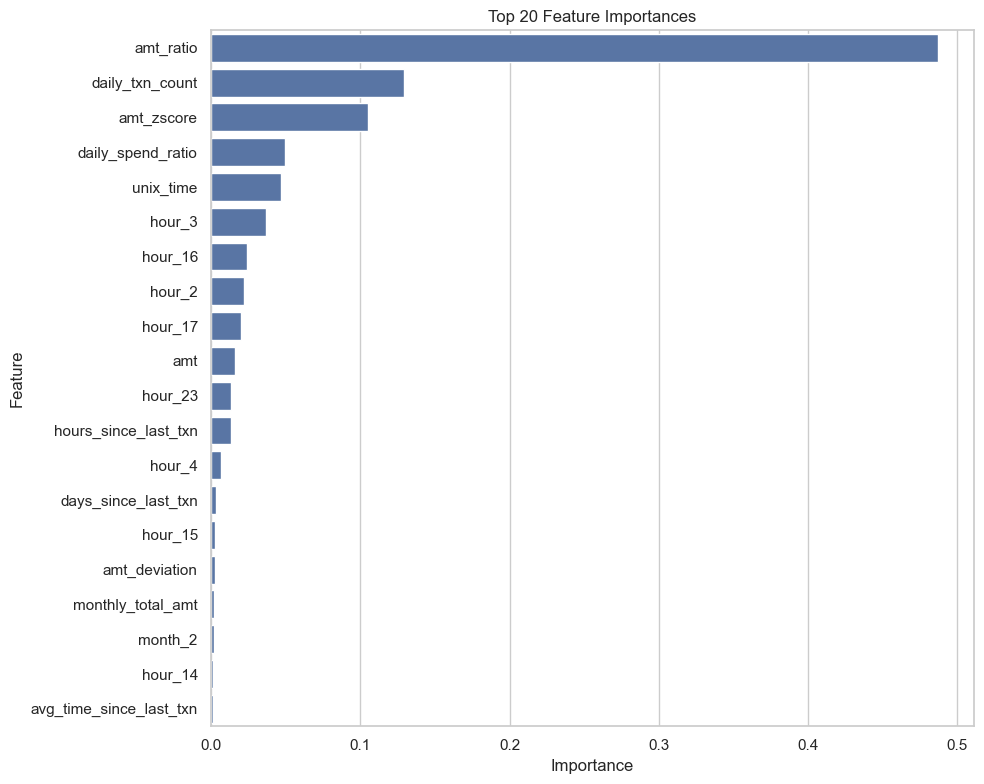

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance_df.head(20),
    y='Feature',
    x='Importance'
)

plt.title(
    'Top 20 Feature Importances'
)

plt.tight_layout()

plt.show()

In [ ]:
bad_features = [
    'trans_date_trans_time',
    'cc_num',
    'first',
    'last'
]

top_features = [f for f in top_features if f not in bad_features]

print("Final Features Used:")
print(top_features)

Final Features Used:
['daily_spend_ratio', 'is_night', 'daily_txn_count', 'amt', 'hour_2', 'daily_count_unique_merchants_per_card', 'hour_17', 'avg_amt_per_card', 'amt_deviation', 'time_since_last_txn', 'daily_total_amt', 'hour_21', 'hour_0', 'hour_22', 'month_12', 'amt_zscore', 'hour_3', 'hour_10', 'hour_23', 'monthly_spend_ratio', 'amt_ratio', 'hour_8', 'hour_1', 'avg_time_since_last_txn', 'hour_4', 'monthly_txn_count', 'unix_time', 'monthly_total_amt', 'tx_count_per_card', 'std_amt_per_card', 'unique_merchants_per_card', 'historical_monthly_avg', 'historical_daily_avg', 'month_2', 'hour_20', 'hour_7', 'avg_days_since_last_txn', 'hour_6', 'hour_18', 'hour_11', 'hour_16', 'hour_9', 'hour_19', 'hour_12', 'hours_since_last_txn', 'days_since_last_txn', 'hour_14', 'hour_13', 'hour_15']


**Data Preparation**

In [ ]:
df = df.sort_values(
    'trans_date_trans_time'
)

train_size = int(len(df) * 0.70)

test_size = int(len(df) * 0.15)

train_df = df.iloc[:train_size]

test_df = df.iloc[
    train_size:
    train_size + test_size
]

oot_df = df.iloc[
    train_size + test_size:
]

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)
print("OOT Shape:", oot_df.shape)

print("\nDate Ranges")

print(
    "Train:",
    train_df['trans_date_trans_time'].min(),
    "to",
    train_df['trans_date_trans_time'].max()
)

print(
    "Test:",
    test_df['trans_date_trans_time'].min(),
    "to",
    test_df['trans_date_trans_time'].max()
)

print(
    "OOT:",
    oot_df['trans_date_trans_time'].min(),
    "to",
    oot_df['trans_date_trans_time'].max()
)

print("\nFraud Rates")

print(
    "Train:",
    train_df['is_fraud'].mean()
)

print(
    "Test:",
    test_df['is_fraud'].mean()
)

print(
    "OOT:",
    oot_df['is_fraud'].mean()
)

Train Shape: (1296675, 107)
Test Shape: (277859, 107)
OOT Shape: (277860, 107)

Date Ranges
Train: 2019-01-01 00:00:18 to 2020-06-21 12:13:37
Test: 2020-06-21 12:14:25 to 2020-10-03 00:58:23
OOT: 2020-10-03 00:59:48 to 2020-12-31 23:59:34

Fraud Rates
Train: 0.005788651743883394
Test: 0.0043943151022640976
OOT: 0.00332541567695962


In [ ]:
# ==========================================
# RAW FEATURE DATASETS
# ==========================================

raw_features = [
    'cc_num',
    'amt',
    'zip',
    'lat',
    'long',
    'city_pop',
    'unix_time',
    'merch_lat',
    'merch_long'
]

X_train_raw = train_df[raw_features].copy()
y_train_raw = train_df['is_fraud'].copy()

X_test_raw = test_df[raw_features].copy()
y_test_raw = test_df['is_fraud'].copy()

X_oot_raw = oot_df[raw_features].copy()
y_oot_raw = oot_df['is_fraud'].copy()

from sklearn.preprocessing import StandardScaler

raw_scaler = StandardScaler()

X_train_raw_scaled = raw_scaler.fit_transform(
    X_train_raw
)

X_test_raw_scaled = raw_scaler.transform(
    X_test_raw
)

X_oot_raw_scaled = raw_scaler.transform(
    X_oot_raw
)

print("Raw Train Shape:", X_train_raw.shape)
print("Raw Test Shape:", X_test_raw.shape)
print("Raw OOT Shape:", X_oot_raw.shape)

Raw Train Shape: (1296675, 9)
Raw Test Shape: (277859, 9)
Raw OOT Shape: (277860, 9)


In [ ]:
selected_features_pre_filter = corr_cols.copy()

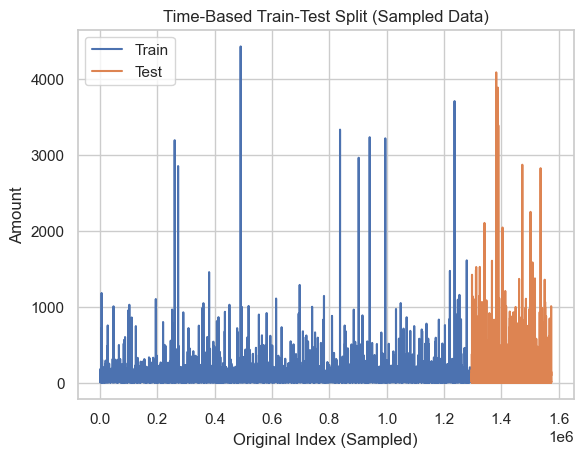

In [ ]:
plt.figure()

# Sample data for plotting to avoid OverflowError with large datasets
sample_size = 10000

# Sample from train_df while maintaining chronological order
if len(train_df) > sample_size:
    train_df_sampled = train_df.sample(n=sample_size, random_state=42).sort_index()
else:
    train_df_sampled = train_df

# Sample from test_df while maintaining chronological order
if len(test_df) > sample_size:
    test_df_sampled = test_df.sample(n=sample_size, random_state=42).sort_index()
else:
    test_df_sampled = test_df

plt.plot(train_df_sampled['amt'], label='Train')
plt.plot(test_df_sampled['amt'], label='Test')
plt.legend()
plt.title('Time-Based Train-Test Split (Sampled Data)')
plt.xlabel('Original Index (Sampled)')
plt.ylabel('Amount')
plt.show()

In [ ]:
# Define X and y for train, test, and oot datasets
X_train = train_df[selected_features_pre_filter].copy()
y_train = train_df['is_fraud'].copy()

X_test = test_df[selected_features_pre_filter].copy()
y_test = test_df['is_fraud'].copy()

X_oot = oot_df[selected_features_pre_filter].copy()
y_oot = oot_df['is_fraud'].copy()

In [ ]:
# TEMP XGBOOST (FOR FEATURE SELECTION)

from xgboost import XGBClassifier

temp_xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

temp_xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# SELECT TOP FEATURES

importance_series = pd.Series(
    temp_xgb.feature_importances_,
    index=X_train.columns  # IMPORTANT: use original columns
)

top_features = importance_series.sort_values(ascending=False).head(50).index.tolist()

print("Selected features:", top_features)

Selected features: ['daily_total_amt', 'is_night', 'amt', 'hour_0', 'daily_spend_ratio', 'hour_2', 'amt_deviation', 'daily_txn_count', 'hour_1', 'historical_monthly_avg', 'hour_3', 'hour_22', 'daily_count_unique_merchants_per_card', 'amt_ratio', 'time_since_last_txn', 'monthly_spend_ratio', 'amt_zscore', 'month_12', 'avg_amt_per_card', 'historical_daily_avg', 'hour_23', 'hour_4', 'tx_count_per_card', 'unix_time', 'avg_time_since_last_txn', 'monthly_total_amt', 'monthly_txn_count', 'hour_8', 'month_2', 'std_amt_per_card', 'hour_7', 'unique_merchants_per_card', 'avg_days_since_last_txn', 'hour_21', 'hour_19', 'hour_9', 'hour_20', 'hour_6', 'hour_14', 'days_since_last_txn', 'hours_since_last_txn', 'hour_17', 'hour_16', 'hour_15', 'hour_13', 'hour_11', 'hour_12', 'hour_10', 'hour_18']


In [ ]:
# REBUILD DATASET WITH TOP FEATURES

X_train = X_train[top_features].fillna(0)

X_test = X_test[top_features].fillna(0)

X_oot = X_oot[top_features].fillna(0)

In [ ]:
# RE-SAMPLING + SCALING
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler

# Fill any potential NaN values in the feature sets with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)
X_oot = X_oot.fillna(0)

# BASELINE DATA
X_train_base = X_train.copy()
y_train_base = y_train.copy()

scaler_base = StandardScaler()

X_train_base_scaled = scaler_base.fit_transform(
    X_train_base
)

X_test_base_scaled = scaler_base.transform(
    X_test
)

X_oot_base_scaled = scaler_base.transform(
    X_oot
)

# UNDERSAMPLED DATA
rus = RandomUnderSampler(
    sampling_strategy=0.1,
    random_state=42
)

X_train_res, y_train_res = rus.fit_resample(
    X_train,
    y_train
)

# # # # #

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_res
)

X_test_scaled = scaler.transform(
    X_test
)

X_oot_scaled = scaler.transform(
    X_oot
)

print("Original Train Shape:", X_train.shape)
print("Resampled Shape:", X_train_res.shape)

print("\nOriginal Fraud Rate:")
print(y_train.value_counts(normalize=True))

print("\nAfter Resample:")
print(y_train_res.value_counts(normalize=True))

Original Train Shape: (1296675, 49)
Resampled Shape: (82566, 49)

Original Fraud Rate:
is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

After Resample:
is_fraud
0    0.909091
1    0.090909
Name: proportion, dtype: float64


In [ ]:
# ==========================================
# CREATE FOLDERS
# ==========================================

import os

os.makedirs(
    "Saved Models",
    exist_ok=True
)

print("Saved Models folder ready!")

Saved Models folder ready!


**LOG REG**

===== BASELINE LOGISTIC REGRESSION =====

TRAIN RESULTS
Precision: 0.8529411764705882
Recall: 0.5331734612310152
F1: 0.6561731431382194

TEST RESULTS
Precision: 0.7334754797441365
Recall: 0.5634725634725635
F1: 0.6373320981936081
ROC-AUC: 0.9770936598451256
Average Precision: 0.6851409796725819

OOT RESULTS
Precision: 0.6540803897685749
Recall: 0.5811688311688312
F1: 0.6154727793696275
ROC-AUC: 0.9737265588861267
Average Precision: 0.6367247986393303

GENERALIZATION
Train-Test Gap: 0.0188
Train-OOT Gap: 0.0407


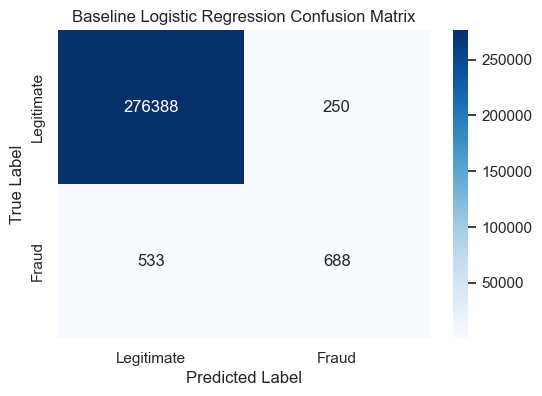


Baseline Logistic Regression model saved!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ==========================================
# BASELINE LOGISTIC REGRESSION
# ==========================================

baseline_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

baseline_model.fit(
    X_train_base_scaled,
    y_train_base
)

# ==========================================
# TRAIN RESULTS
# ==========================================

y_train_pred_base = baseline_model.predict(
    X_train_base_scaled
)

train_precision_base = precision_score(
    y_train_base,
    y_train_pred_base,
    zero_division=0
)

train_recall_base = recall_score(
    y_train_base,
    y_train_pred_base
)

train_f1_base = f1_score(
    y_train_base,
    y_train_pred_base
)

print("===== BASELINE LOGISTIC REGRESSION =====")

print("\nTRAIN RESULTS")
print("Precision:", train_precision_base)
print("Recall:", train_recall_base)
print("F1:", train_f1_base)

# ==========================================
# TEST RESULTS
# ==========================================

y_prob_base = baseline_model.predict_proba(
    X_test_base_scaled
)[:, 1]

y_pred_base = (
    y_prob_base >= 0.5
).astype(int)

precision_base = precision_score(
    y_test,
    y_pred_base,
    zero_division=0
)

recall_base = recall_score(
    y_test,
    y_pred_base
)

f1_base = f1_score(
    y_test,
    y_pred_base
)

roc_auc_base = roc_auc_score(
    y_test,
    y_prob_base
)

ap_base = average_precision_score(
    y_test,
    y_prob_base
)

print("\nTEST RESULTS")
print("Precision:", precision_base)
print("Recall:", recall_base)
print("F1:", f1_base)
print("ROC-AUC:", roc_auc_base)
print("Average Precision:", ap_base)

# ==========================================
# OOT RESULTS
# ==========================================

y_prob_oot_base = baseline_model.predict_proba(
    X_oot_base_scaled
)[:, 1]

y_pred_oot_base = (
    y_prob_oot_base >= 0.5
).astype(int)

oot_precision_base = precision_score(
    y_oot,
    y_pred_oot_base,
    zero_division=0
)

oot_recall_base = recall_score(
    y_oot,
    y_pred_oot_base
)

oot_f1_base = f1_score(
    y_oot,
    y_pred_oot_base
)

oot_roc_auc_base = roc_auc_score(
    y_oot,
    y_prob_oot_base
)

oot_ap_base = average_precision_score(
    y_oot,
    y_prob_oot_base
)

print("\nOOT RESULTS")
print("Precision:", oot_precision_base)
print("Recall:", oot_recall_base)
print("F1:", oot_f1_base)
print("ROC-AUC:", oot_roc_auc_base)
print("Average Precision:", oot_ap_base)

# ==========================================
# GENERALIZATION
# ==========================================

print("\nGENERALIZATION")

print(
    f"Train-Test Gap: {train_f1_base - f1_base:.4f}"
)

print(
    f"Train-OOT Gap: {train_f1_base - oot_f1_base:.4f}"
)

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred_base
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.title(
    "Baseline Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# ==========================================
# SAVE MODEL
# ==========================================

with open(
    "Saved Models/baseline_logistic_regression.pkl",
    "wb"
) as f:

    pickle.dump(
        baseline_model,
        f
    )

print("\nBaseline Logistic Regression model saved!")

===== TUNED LOGISTIC REGRESSION =====

TRAIN RESULTS
Precision: 0.9259259259259259
Recall: 0.8060218491873168
F1: 0.8618233618233618

TEST RESULTS
Precision: 0.7389428263214671
Recall: 0.561015561015561
F1: 0.6378026070763501
ROC-AUC: 0.9788698126200567
Average Precision: 0.6469594749593709

OOT RESULTS
Precision: 0.6440886699507389
Recall: 0.566017316017316
F1: 0.6025345622119815
ROC-AUC: 0.9761084210370328
Average Precision: 0.563680137601153

GENERALIZATION
Train-Test Gap: 0.2240
Train-OOT Gap: 0.2593


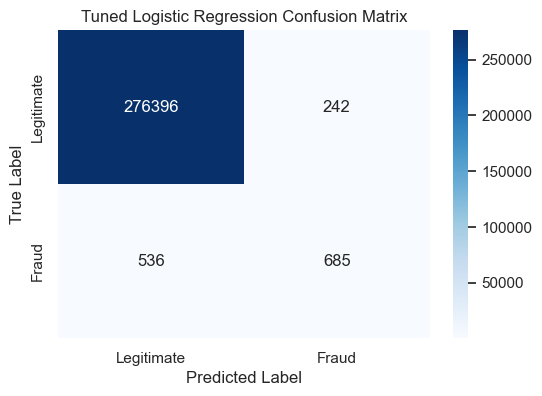


Tuned Logistic Regression model saved!
Decision threshold saved!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ==========================================
# TUNED LOGISTIC REGRESSION
# ==========================================

model_eng = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_eng.fit(
    X_train_scaled,
    y_train_res
)

# ==========================================
# TRAIN RESULTS
# ==========================================

y_train_pred_eng = model_eng.predict(
    X_train_scaled
)

train_precision_eng = precision_score(
    y_train_res,
    y_train_pred_eng,
    zero_division=0
)

train_recall_eng = recall_score(
    y_train_res,
    y_train_pred_eng
)

train_f1_eng = f1_score(
    y_train_res,
    y_train_pred_eng
)

print("===== TUNED LOGISTIC REGRESSION =====")

print("\nTRAIN RESULTS")
print("Precision:", train_precision_eng)
print("Recall:", train_recall_eng)
print("F1:", train_f1_eng)

# ==========================================
# TEST RESULTS
# ==========================================

threshold = 0.95

y_prob_eng = model_eng.predict_proba(
    X_test_scaled
)[:,1]

y_pred_eng = (
    y_prob_eng >= threshold
).astype(int)

precision_eng = precision_score(
    y_test,
    y_pred_eng,
    zero_division=0
)

recall_eng = recall_score(
    y_test,
    y_pred_eng
)

f1_eng = f1_score(
    y_test,
    y_pred_eng
)

roc_auc_eng = roc_auc_score(
    y_test,
    y_prob_eng
)

ap_eng = average_precision_score(
    y_test,
    y_prob_eng
)

print("\nTEST RESULTS")
print("Precision:", precision_eng)
print("Recall:", recall_eng)
print("F1:", f1_eng)
print("ROC-AUC:", roc_auc_eng)
print("Average Precision:", ap_eng)

# ==========================================
# OOT RESULTS
# ==========================================

y_prob_oot_eng = model_eng.predict_proba(
    X_oot_scaled
)[:,1]

y_pred_oot_eng = (
    y_prob_oot_eng >= threshold
).astype(int)

oot_precision_eng = precision_score(
    y_oot,
    y_pred_oot_eng,
    zero_division=0
)

oot_recall_eng = recall_score(
    y_oot,
    y_pred_oot_eng
)

oot_f1_eng = f1_score(
    y_oot,
    y_pred_oot_eng
)

oot_roc_auc_eng = roc_auc_score(
    y_oot,
    y_prob_oot_eng
)

oot_ap_eng = average_precision_score(
    y_oot,
    y_prob_oot_eng
)

print("\nOOT RESULTS")
print("Precision:", oot_precision_eng)
print("Recall:", oot_recall_eng)
print("F1:", oot_f1_eng)
print("ROC-AUC:", oot_roc_auc_eng)
print("Average Precision:", oot_ap_eng)

# ==========================================
# GENERALIZATION
# ==========================================

print("\nGENERALIZATION")

print(
    f"Train-Test Gap: {train_f1_eng - f1_eng:.4f}"
)

print(
    f"Train-OOT Gap: {train_f1_eng - oot_f1_eng:.4f}"
)

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred_eng
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.title(
    "Tuned Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# ==========================================
# SAVE MODEL
# ==========================================

with open(
    "Saved Models/tuned_logistic_regression.pkl",
    "wb"
) as f:

    pickle.dump(
        model_eng,
        f
    )

print("\nTuned Logistic Regression model saved!")

# ==========================================
# SAVE THRESHOLD
# ==========================================

with open(
    "Saved Models/tuned_logistic_regression_threshold.pkl",
    "wb"
) as f:

    pickle.dump(
        threshold,
        f
    )

print("Decision threshold saved!")

**XGBOOST**

===== RAW FEATURE XGBOOST =====

TRAIN RESULTS
Precision: 0.5770368378596397
Recall: 0.2859046096456168
F1: 0.3823608017817372

TEST RESULTS
Precision: 0.20993788819875778
Recall: 0.13841113841113842
F1: 0.16683119447186576
ROC-AUC: 0.748591489888781
Average Precision: 0.09670650811205408

OOT RESULTS
Precision: 0.18610747051114024
Recall: 0.15367965367965367
F1: 0.16834617664493184
ROC-AUC: 0.749556240946851
Average Precision: 0.0789841872965305

GENERALIZATION
Train-Test Gap: 0.2155
Train-OOT Gap: 0.2140


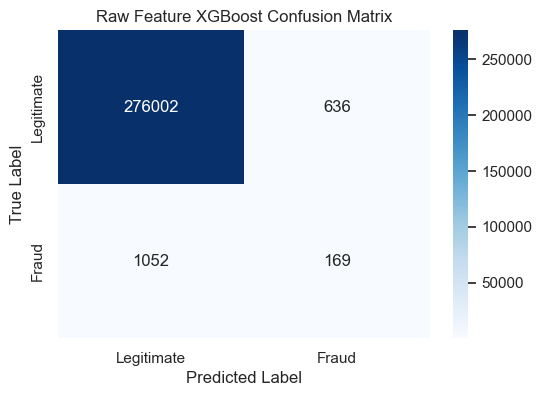


Raw Feature XGBoost model saved!


In [ ]:
# ==========================================
# RAW FEATURE XGBOOST
# ==========================================

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

raw_xgb = xgb.XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

raw_xgb.fit(
    X_train_raw,
    y_train_raw
)

# ==========================================
# TRAIN RESULTS
# ==========================================

y_train_pred_raw = raw_xgb.predict(
    X_train_raw
)

train_precision_raw = precision_score(
    y_train_raw,
    y_train_pred_raw,
    zero_division=0
)

train_recall_raw = recall_score(
    y_train_raw,
    y_train_pred_raw
)

train_f1_raw = f1_score(
    y_train_raw,
    y_train_pred_raw
)

print("===== RAW FEATURE XGBOOST =====")

print("\nTRAIN RESULTS")
print("Precision:", train_precision_raw)
print("Recall:", train_recall_raw)
print("F1:", train_f1_raw)

# ==========================================
# TEST RESULTS
# ==========================================

y_prob_raw = raw_xgb.predict_proba(
    X_test_raw
)[:,1]

y_pred_raw = (
    y_prob_raw >= 0.5
).astype(int)

precision_raw = precision_score(
    y_test_raw,
    y_pred_raw,
    zero_division=0
)

recall_raw = recall_score(
    y_test_raw,
    y_pred_raw
)

f1_raw = f1_score(
    y_test_raw,
    y_pred_raw
)

roc_auc_raw = roc_auc_score(
    y_test_raw,
    y_prob_raw
)

ap_raw = average_precision_score(
    y_test_raw,
    y_prob_raw
)

print("\nTEST RESULTS")
print("Precision:", precision_raw)
print("Recall:", recall_raw)
print("F1:", f1_raw)
print("ROC-AUC:", roc_auc_raw)
print("Average Precision:", ap_raw)

# ==========================================
# OOT RESULTS
# ==========================================

y_prob_oot_raw = raw_xgb.predict_proba(
    X_oot_raw
)[:,1]

y_pred_oot_raw = (
    y_prob_oot_raw >= 0.5
).astype(int)

oot_precision_raw = precision_score(
    y_oot_raw,
    y_pred_oot_raw,
    zero_division=0
)

oot_recall_raw = recall_score(
    y_oot_raw,
    y_pred_oot_raw
)

oot_f1_raw = f1_score(
    y_oot_raw,
    y_pred_oot_raw
)

oot_roc_auc_raw = roc_auc_score(
    y_oot_raw,
    y_prob_oot_raw
)

oot_ap_raw = average_precision_score(
    y_oot_raw,
    y_prob_oot_raw
)

print("\nOOT RESULTS")
print("Precision:", oot_precision_raw)
print("Recall:", oot_recall_raw)
print("F1:", oot_f1_raw)
print("ROC-AUC:", oot_roc_auc_raw)
print("Average Precision:", oot_ap_raw)

# ==========================================
# GENERALIZATION
# ==========================================

print("\nGENERALIZATION")

print(
    f"Train-Test Gap: {train_f1_raw - f1_raw:.4f}"
)

print(
    f"Train-OOT Gap: {train_f1_raw - oot_f1_raw:.4f}"
)

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test_raw,
    y_pred_raw
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.title(
    "Raw Feature XGBoost Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# ==========================================
# SAVE MODEL
# ==========================================

with open(
    "Saved Models/raw_feature_xgboost.pkl",
    "wb"
) as f:

    pickle.dump(
        raw_xgb,
        f
    )

print("\nRaw Feature XGBoost model saved!")

===== BASELINE XGBOOST =====

TRAIN RESULTS
Precision: 0.941073512252042
Recall: 0.8595790034638956
F1: 0.8984821055563292

TEST RESULTS
Precision: 0.7813588850174216
Recall: 0.7346437346437347
F1: 0.7572815533980582
ROC-AUC: 0.9719023697544364
Average Precision: 0.7577933942657654

OOT RESULTS
Precision: 0.7096092925026399
Recall: 0.7272727272727273
F1: 0.7183324425440941
ROC-AUC: 0.9660531612661346
Average Precision: 0.7051389968670683

GENERALIZATION
Train-Test Gap: 0.1412
Train-OOT Gap: 0.1801


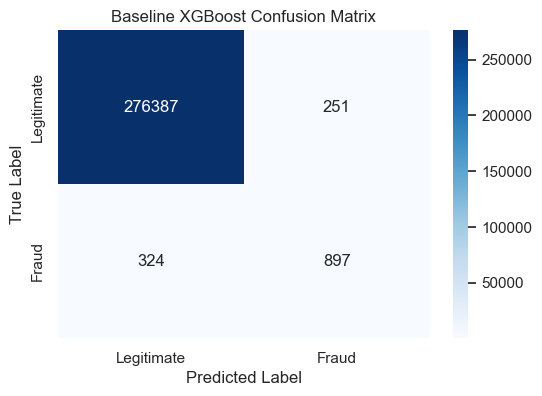


Baseline XGBoost model saved!


In [ ]:
# ==========================================
# BASELINE XGBOOST
# ==========================================

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

baseline_xgb = xgb.XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

baseline_xgb.fit(
    X_train,
    y_train
)

# ==========================================
# TRAIN RESULTS
# ==========================================

y_train_pred_xgb_base = baseline_xgb.predict(
    X_train
)

train_precision_xgb_base = precision_score(
    y_train,
    y_train_pred_xgb_base,
    zero_division=0
)

train_recall_xgb_base = recall_score(
    y_train,
    y_train_pred_xgb_base
)

train_f1_xgb_base = f1_score(
    y_train,
    y_train_pred_xgb_base
)

print("===== BASELINE XGBOOST =====")

print("\nTRAIN RESULTS")
print("Precision:", train_precision_xgb_base)
print("Recall:", train_recall_xgb_base)
print("F1:", train_f1_xgb_base)

# ==========================================
# TEST RESULTS
# ==========================================

y_prob_xgb_base = baseline_xgb.predict_proba(
    X_test
)[:,1]

y_pred_xgb_base = (
    y_prob_xgb_base >= 0.5
).astype(int)

precision_xgb_base = precision_score(
    y_test,
    y_pred_xgb_base,
    zero_division=0
)

recall_xgb_base = recall_score(
    y_test,
    y_pred_xgb_base
)

f1_xgb_base = f1_score(
    y_test,
    y_pred_xgb_base
)

roc_auc_xgb_base = roc_auc_score(
    y_test,
    y_prob_xgb_base
)

ap_xgb_base = average_precision_score(
    y_test,
    y_prob_xgb_base
)

print("\nTEST RESULTS")
print("Precision:", precision_xgb_base)
print("Recall:", recall_xgb_base)
print("F1:", f1_xgb_base)
print("ROC-AUC:", roc_auc_xgb_base)
print("Average Precision:", ap_xgb_base)

# ==========================================
# OOT RESULTS
# ==========================================

y_prob_oot_xgb_base = baseline_xgb.predict_proba(
    X_oot
)[:,1]

y_pred_oot_xgb_base = (
    y_prob_oot_xgb_base >= 0.5
).astype(int)

oot_precision_xgb_base = precision_score(
    y_oot,
    y_pred_oot_xgb_base,
    zero_division=0
)

oot_recall_xgb_base = recall_score(
    y_oot,
    y_pred_oot_xgb_base
)

oot_f1_xgb_base = f1_score(
    y_oot,
    y_pred_oot_xgb_base
)

oot_roc_auc_xgb_base = roc_auc_score(
    y_oot,
    y_prob_oot_xgb_base
)

oot_ap_xgb_base = average_precision_score(
    y_oot,
    y_prob_oot_xgb_base
)

print("\nOOT RESULTS")
print("Precision:", oot_precision_xgb_base)
print("Recall:", oot_recall_xgb_base)
print("F1:", oot_f1_xgb_base)
print("ROC-AUC:", oot_roc_auc_xgb_base)
print("Average Precision:", oot_ap_xgb_base)

# ==========================================
# GENERALIZATION
# ==========================================

print("\nGENERALIZATION")
print(
    f"Train-Test Gap: {train_f1_xgb_base - f1_xgb_base:.4f}"
)
print(
    f"Train-OOT Gap: {train_f1_xgb_base - oot_f1_xgb_base:.4f}"
)

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred_xgb_base
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.title(
    "Baseline XGBoost Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# ==========================================
# SAVE MODEL
# ==========================================

with open(
    "Saved Models/baseline_xgboost.pkl",
    "wb"
) as f:

    pickle.dump(
        baseline_xgb,
        f
    )

print("\nBaseline XGBoost model saved!")

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

import xgboost as xgb
import numpy as np
import pandas as pd

# ==========================================
# FINAL PARAMETER COMBINATION
# ==========================================

best_params = {
    "learning_rate": 0.01,
    "max_depth": 8,
    "n_estimators": 400,
    "subsample": 0.6
}

print("Using final tuned XGBoost parameters:")
print(best_params)

# ==========================================
# TRAIN MODEL
# ==========================================

model = xgb.XGBClassifier(
    **best_params,
    eval_metric="logloss",
    random_state=42
)

model.fit(
    X_train_base_scaled,
    y_train
)

# ==========================================
# TRAIN METRICS
# ==========================================

y_train_pred = model.predict(
    X_train_base_scaled
)

train_precision = precision_score(
    y_train,
    y_train_pred,
    zero_division=0
)

train_recall = recall_score(
    y_train,
    y_train_pred
)

train_f1 = f1_score(
    y_train,
    y_train_pred
)

print("\n===== TRAIN =====")
print("Precision:", round(train_precision,4))
print("Recall:", round(train_recall,4))
print("F1:", round(train_f1,4))

# ==========================================
# TEST PROBABILITIES
# ==========================================

y_prob = model.predict_proba(
    X_test_base_scaled
)[:,1]

# ==========================================
# THRESHOLD SEARCH
# ==========================================

thresholds = np.linspace(
    0.20,
    0.95,
    30
)

best_t = 0.4069
best_score = 0

for t in thresholds:

    y_pred_tmp = (
        y_prob >= t
    ).astype(int)

    f1_tmp = f1_score(
        y_test,
        y_pred_tmp
    )

    if f1_tmp > best_score:

        best_score = f1_tmp
        best_t = t

print("\nBest Threshold:", round(best_t,4))
print("Best Test F1:", round(best_score,4))

# ==========================================
# FINAL TEST METRICS
# ==========================================

y_pred = (
    y_prob >= best_t
).astype(int)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

ap = average_precision_score(
    y_test,
    y_prob
)

print("\n===== TEST =====")
print("Precision:", round(precision,4))
print("Recall:", round(recall,4))
print("F1:", round(f1,4))
print("ROC-AUC:", round(roc_auc,4))
print("Average Precision:", round(ap,4))

# ==========================================
# OOT METRICS
# ==========================================

y_prob_oot = model.predict_proba(
    X_oot_base_scaled
)[:,1]

y_pred_oot = (
    y_prob_oot >= best_t
).astype(int)

oot_precision = precision_score(
    y_oot,
    y_pred_oot,
    zero_division=0
)

oot_recall = recall_score(
    y_oot,
    y_pred_oot
)

oot_f1 = f1_score(
    y_oot,
    y_pred_oot
)

oot_roc_auc = roc_auc_score(
    y_oot,
    y_prob_oot
)

oot_ap = average_precision_score(
    y_oot,
    y_prob_oot
)

print("\n===== OOT =====")
print("Precision:", round(oot_precision,4))
print("Recall:", round(oot_recall,4))
print("F1:", round(oot_f1,4))
print("ROC-AUC:", round(oot_roc_auc,4))
print("Average Precision:", round(oot_ap,4))

# ==========================================
# GENERALIZATION
# ==========================================

train_test_gap = train_f1 - f1
train_oot_gap = train_f1 - oot_f1

print("\n===== GENERALIZATION =====")
print("Train-Test Gap:", round(train_test_gap,4))
print("Train-OOT Gap:", round(train_oot_gap,4))

# ==========================================
# COMPARISON TABLE
# ==========================================

evaluation_results = []

evaluation_results.append({

    "Rank": 1,
    "Mean CV F1": np.nan,
    "Std Dev": np.nan,

    "Train Precision": train_precision,
    "Train Recall": train_recall,
    "Train F1": train_f1,

    "Best Threshold": best_t,

    "Test Precision": precision,
    "Test Recall": recall,
    "Test F1": f1,
    "Test ROC-AUC": roc_auc,
    "Test AP": ap,

    "OOT Precision": oot_precision,
    "OOT Recall": oot_recall,
    "OOT F1": oot_f1,
    "OOT ROC-AUC": oot_roc_auc,
    "OOT AP": oot_ap,

    "CV-Test Gap": np.nan,
    "CV-OOT Gap": np.nan,

    "Train-Test Gap": train_test_gap,
    "Train-OOT Gap": train_oot_gap,

    "Parameters": best_params

})

comparison_df = pd.DataFrame(
    evaluation_results
)

comparison_df = comparison_df.round(4)

print("\n===== FINAL TUNED XGBOOST RESULTS =====")
display(comparison_df)

comparison_df.to_excel(
    "Final_Tuned_XGBoost_Results.xlsx",
    index=False
)

print("\nResults saved to 'Final_Tuned_XGBoost_Results.xlsx'")

# ==========================================
# FINAL MODEL
# ==========================================

final_xgb = model

with open(
    "Saved Models/tuned_xgboost.pkl",
    "wb"
) as f:

    pickle.dump(
        final_xgb,
        f
    )

print("\nTuned XGBoost model saved!")

Using final tuned XGBoost parameters:
{'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 400, 'subsample': 0.6}

===== TRAIN =====
Precision: 0.9731
Recall: 0.7955
F1: 0.8754

Best Threshold: 0.4069
Best Test F1: 0.8163

===== TEST =====
Precision: 0.8859
Recall: 0.7568
F1: 0.8163
ROC-AUC: 0.9938
Average Precision: 0.8742

===== OOT =====
Precision: 0.8408
Recall: 0.7489
F1: 0.7922
ROC-AUC: 0.9945
Average Precision: 0.8486

===== GENERALIZATION =====
Train-Test Gap: 0.0591
Train-OOT Gap: 0.0832

===== FINAL TUNED XGBOOST RESULTS =====


,Rank,Mean CV F1,Std Dev,Train Precision,Train Recall,Train F1,Best Threshold,Test Precision,Test Recall,Test F1,...,OOT Precision,OOT Recall,OOT F1,OOT ROC-AUC,OOT AP,CV-Test Gap,CV-OOT Gap,Train-Test Gap,Train-OOT Gap,Parameters
0,1,NaN,NaN,0.9731,0.7955,0.8754,0.4069,0.8859,0.7568,0.8163,...,0.8408,0.7489,0.7922,0.9945,0.8486,NaN,NaN,0.0591,0.0832,"{'learning_rate': 0.01, 'max_depth': 8, 'n_est..."



Results saved to 'Final_Tuned_XGBoost_Results.xlsx'

Tuned XGBoost model saved!


In [ ]:
# ==========================================
# FINAL MODEL PREDICTIONS
# ==========================================

y_prob_xgb = final_xgb.predict_proba(
    X_test_base_scaled
)[:,1]

y_pred_xgb = (
    y_prob_xgb >= best_t
).astype(int)

y_prob_oot_xgb = final_xgb.predict_proba(
    X_oot_base_scaled
)[:,1]

y_pred_oot_xgb = (
    y_prob_oot_xgb >= best_t
).astype(int)

In [ ]:
from sklearn.metrics import roc_auc_score

y_prob_xgb = final_xgb.predict_proba(
    X_test_base_scaled
)[:,1]

auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("ROC-AUC:", auc)

ROC-AUC: 0.9938178668866428


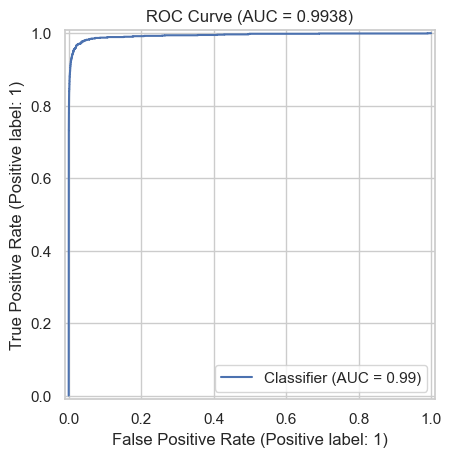

In [ ]:
from sklearn.metrics import (
    RocCurveDisplay,
    roc_auc_score
)

auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb
)

plt.title(
    f"ROC Curve (AUC = {auc:.4f})"
)

plt.show()

Average Precision: 0.8742179666628851


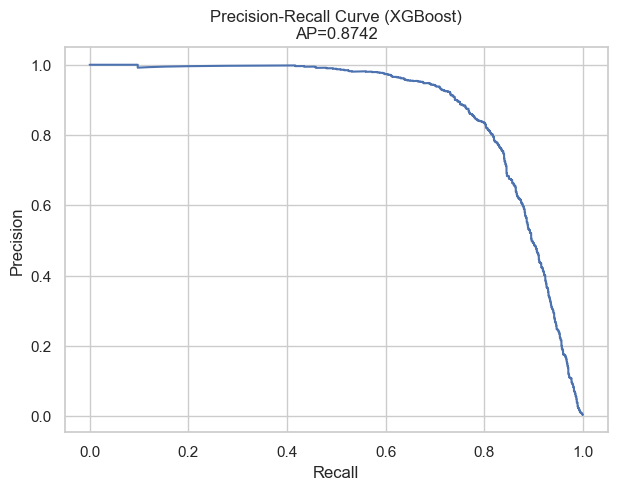

In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob_xgb
)

ap_score = average_precision_score(
    y_test,
    y_prob_xgb
)

print(
    "Average Precision:",
    ap_score
)

plt.figure(figsize=(7,5))
plt.plot(
    recall,
    precision
)
plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)
plt.title(
    f"Precision-Recall Curve (XGBoost)\nAP={ap_score:.4f}"
)

plt.grid(True)

plt.show()

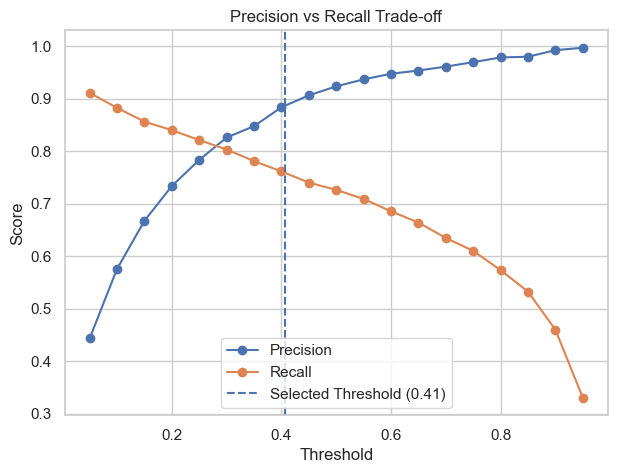

In [ ]:
plt.figure(figsize=(7,5))

thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

precisions = []
recalls = []

for t in thresholds:

    y_pred_t = (
        y_prob_xgb >= t
    ).astype(int)

    precisions.append(
        precision_score(
            y_test,
            y_pred_t,
            zero_division=0
        )
    )

    recalls.append(
        recall_score(
            y_test,
            y_pred_t
        )
    )

plt.plot(
    thresholds,
    precisions,
    marker='o',
    label='Precision'
)

plt.plot(
    thresholds,
    recalls,
    marker='o',
    label='Recall'
)

plt.axvline(
    x=best_t,
    linestyle='--',
    label=f'Selected Threshold ({best_t:.2f})'
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title(
    "Precision vs Recall Trade-off"
)

plt.legend()

plt.grid(True)

plt.show()

                                  Feature  Importance
2                                     amt    0.247511
1                                is_night    0.187821
4                       daily_spend_ratio    0.129743
0                         daily_total_amt    0.053100
21                                 hour_4    0.035778
3                                  hour_0    0.026660
12  daily_count_unique_merchants_per_card    0.026565
7                         daily_txn_count    0.022087
6                           amt_deviation    0.019393
8                                  hour_1    0.018251
14                    time_since_last_txn    0.013509
9                  historical_monthly_avg    0.011963
11                                hour_22    0.011523
10                                 hour_3    0.011262
5                                  hour_2    0.010897
20                                hour_23    0.010850
15                    monthly_spend_ratio    0.010789
16                          

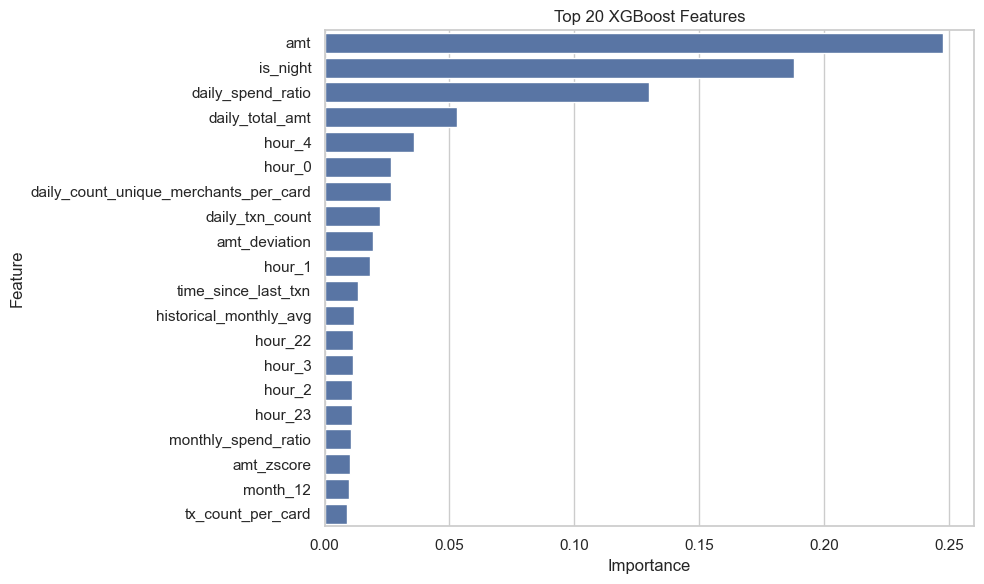

In [ ]:
# XGBOOST FEATURE IMPORTANCE

xgb_importance = pd.DataFrame({
    'Feature': top_features,
    'Importance': final_xgb.feature_importances_
})

xgb_importance = (
    xgb_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

print(
    xgb_importance.head(20)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=xgb_importance.head(20),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 20 XGBoost Features'
)

plt.xlabel(
    'Importance'
)

plt.ylabel(
    'Feature'
)

plt.tight_layout()

plt.show()

**SHAP ANALYSIS**

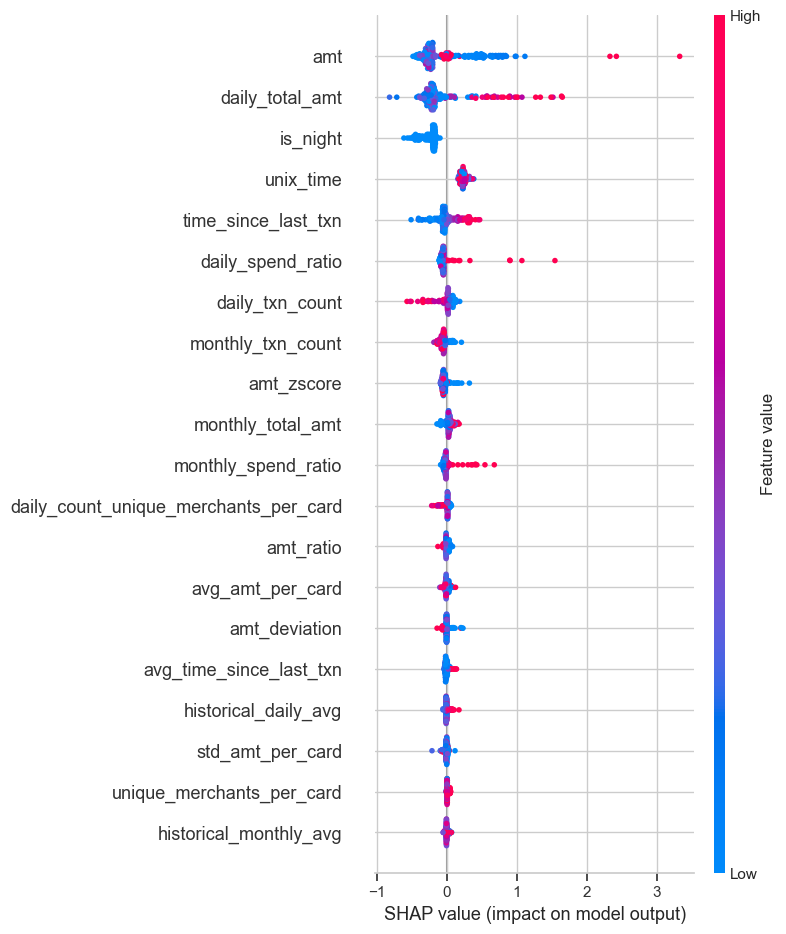

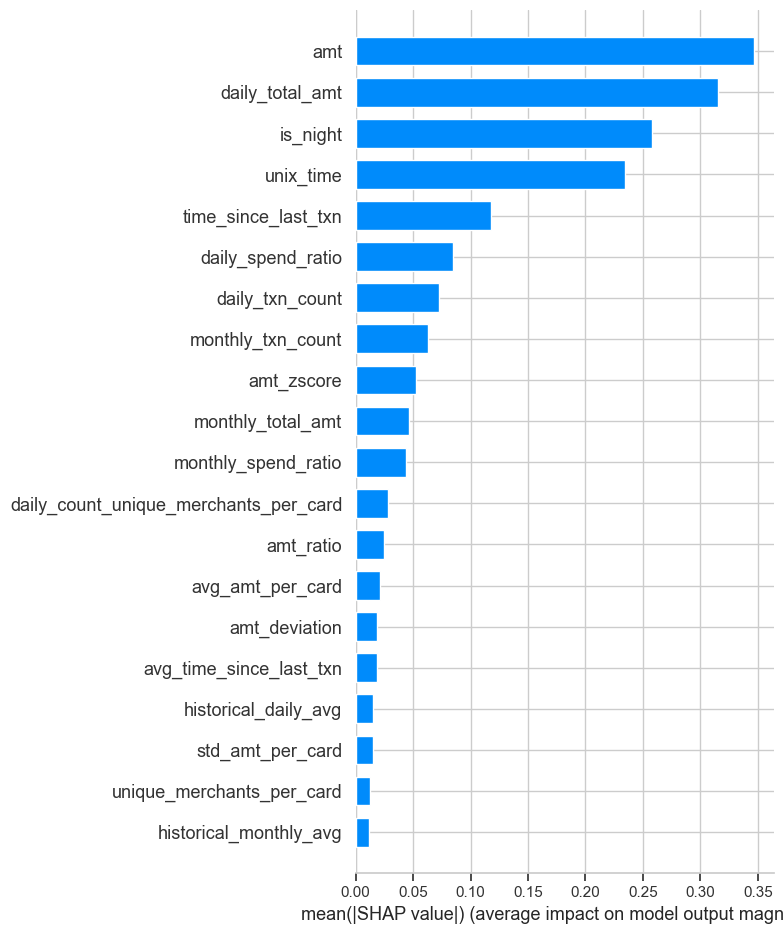

In [ ]:
# SHAP EXPLAINABILITY

explainer = shap.Explainer(
    final_xgb,
    X_train_base_scaled
)

sample_X = X_test_base_scaled[:200]

sample_X_df = X_test.iloc[:200]

shap_values = explainer(
    sample_X
)

# Detailed SHAP Summary

shap.summary_plot(
    shap_values,
    sample_X_df
)

# Global Feature Importance

shap.summary_plot(
    shap_values,
    sample_X_df,
    plot_type="bar"
)

**ERROR ANALYSIS**

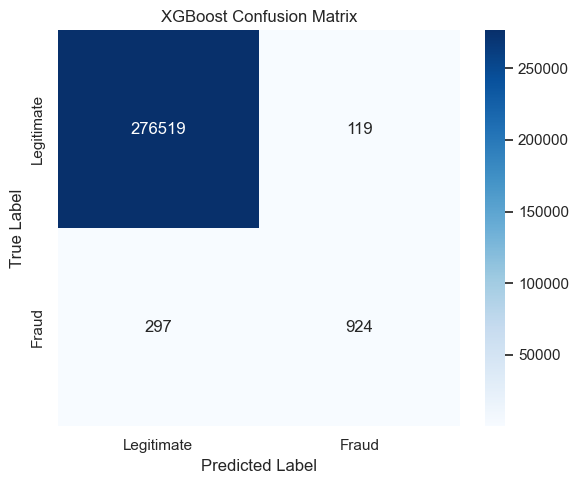

False Positives: 119
False Negatives: 297
Total Errors: 416

--- TOP FP FEATURES ---


unix_time                    1.375467e+09
time_since_last_txn          2.329439e+04
monthly_total_amt            4.374579e+03
historical_monthly_avg       2.789128e+03
tx_count_per_card            1.543471e+03
daily_total_amt              9.805903e+02
amt                          6.036366e+02
unique_merchants_per_card    5.405462e+02
amt_deviation                5.367309e+02
std_amt_per_card             1.386267e+02
dtype: float64


--- TOP FN FEATURES ---


unix_time                    1.376201e+09
time_since_last_txn          3.191314e+04
monthly_total_amt            4.912731e+03
historical_monthly_avg       3.659590e+03
tx_count_per_card            1.945145e+03
unique_merchants_per_card    5.729158e+02
daily_total_amt              4.209667e+02
amt                          2.732125e+02
amt_deviation                2.024999e+02
historical_daily_avg         1.470301e+02
dtype: float64

,daily_total_amt,is_night,amt,hour_0,daily_spend_ratio,hour_2,amt_deviation,daily_txn_count,hour_1,historical_monthly_avg,...,days_since_last_txn,hours_since_last_txn,hour_17,hour_16,hour_15,hour_13,hour_11,hour_12,hour_10,hour_18
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,...,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,420.966705,0.757576,273.212494,0.154882,1.935556,0.107744,202.499855,1.282828,0.131313,3659.590107,...,0.369365,8.864761,0.010101,0.010101,0.023569,0.010101,0.016835,0.006734,0.013468,0.016835
std,868.005310,0.429273,328.862457,0.362403,3.108367,0.310580,330.571252,1.808615,0.338313,1845.765987,...,0.471143,11.307442,0.100164,0.100164,0.151958,0.100164,0.128870,0.081922,0.115462,0.128870
min,0.000000,0.000000,1.990000,0.000000,0.000000,0.000000,-483.414551,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,13.510000,0.000000,0.000000,0.000000,-47.516000,0.000000,0.000000,2088.548559,...,0.063171,1.516111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,132.100006,0.000000,0.000000,0.000000,64.679795,0.000000,0.000000,3538.146724,...,0.189942,4.558611,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,360.709991,1.000000,342.869995,0.000000,2.658707,0.000000,273.296240,2.000000,0.000000,4783.443167,...,0.489676,11.752222,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,4760.930176,1.000000,1319.969971,1.000000,8.517709,1.000000,1259.620196,10.000000,1.000000,8508.182475,...,3.471192,83.308611,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


,daily_total_amt,is_night,amt,hour_0,daily_spend_ratio,hour_2,amt_deviation,daily_txn_count,hour_1,historical_monthly_avg,...,days_since_last_txn,hours_since_last_txn,hour_17,hour_16,hour_15,hour_13,hour_11,hour_12,hour_10,hour_18
count,119.000000,119.000000,119.000000,119.000000,119.000000,119.00000,119.000000,119.000000,119.000000,119.000000,...,119.000000,119.000000,119.000000,119.000000,119.000000,119.0,119.000000,119.0,119.0,119.000000
mean,980.590332,0.857143,603.636597,0.142857,4.427363,0.10084,536.730902,1.831933,0.117647,2789.127783,...,0.269611,6.470665,0.008403,0.016807,0.008403,0.0,0.025210,0.0,0.0,0.008403
std,1301.808594,0.351407,901.212158,0.351407,3.909882,0.30239,902.428777,2.009804,0.323552,1457.243538,...,0.420270,10.086485,0.091670,0.129090,0.091670,0.0,0.157426,0.0,0.0,0.091670
min,0.000000,0.000000,3.200000,0.000000,0.000000,0.00000,-87.620087,0.000000,0.000000,750.554594,...,0.000359,0.008611,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
25%,0.000000,1.000000,20.335000,0.000000,0.000000,0.00000,-45.344767,0.000000,0.000000,1619.868371,...,0.026024,0.624583,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
50%,530.559998,1.000000,308.070007,0.000000,4.904274,0.00000,248.691258,1.000000,0.000000,2867.957124,...,0.099792,2.395000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
75%,1312.525024,1.000000,747.240021,0.000000,8.517709,0.00000,668.123471,3.000000,0.000000,3719.466196,...,0.326719,7.841250,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
max,6427.059570,1.000000,4933.810059,1.000000,8.517709,1.00000,4869.111531,9.000000,1.000000,7829.433635,...,2.475324,59.407778,1.000000,1.000000,1.000000,0.0,1.000000,0.0,0.0,1.000000


,Legitimate,False Positive,False Negative
amt,67.470474,603.636597,273.212494
daily_total_amt,148.358948,980.590332,420.966705
monthly_total_amt,4284.651855,4374.578613,4912.731445
tx_count_per_card,2014.245913,1543.470588,1945.144781
unique_merchants_per_card,594.543103,540.546218,572.915825
time_since_last_txn,29222.235101,23294.394958,31913.138047



Error Rate
False Positive Rate: 0.0428%
False Negative Rate: 0.1069%


In [ ]:
import pandas as pd

# ERROR ANALYSIS

y_pred_final = (
    y_prob_xgb >= best_t
).astype(int)

# ==========================================
# CONFUSION MATRIX
# ==========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost Confusion Matrix")

plt.tight_layout()
plt.show()

fp = X_test[
    (y_pred_final == 1)
    &
    (y_test == 0)
]

fn = X_test[
    (y_pred_final == 0)
    &
    (y_test == 1)
]

# Get actual legitimate transactions for comparison
actual_legit = X_test.loc[
    y_test == 0
]

print(
    f"False Positives: {len(fp):,}"
)

print(
    f"False Negatives: {len(fn):,}"
)

print(
    f"Total Errors: {len(fp)+len(fn):,}"
)

print("\n--- TOP FP FEATURES ---")

display(
    fp.mean(
        numeric_only=True
    )
    .sort_values(
        ascending=False
    )
    .head(10)
)

print("\n--- TOP FN FEATURES ---")

display(
    fn.mean(
        numeric_only=True
    )
    .sort_values(
        ascending=False
    )
    .head(10)
)

display(fn.describe())
display(fp.describe())

comparison = pd.DataFrame({
    'Legitimate': actual_legit.mean(numeric_only=True),
    'False Positive': fp.mean(numeric_only=True),
    'False Negative': fn.mean(numeric_only=True)
})

display(comparison.loc[
[
'amt',
'daily_total_amt',
'monthly_total_amt',
'tx_count_per_card',
'unique_merchants_per_card',
'time_since_last_txn'
]
])

print("\nError Rate")

print(
    f"False Positive Rate: {len(fp)/len(y_test):.4%}"
)

print(
    f"False Negative Rate: {len(fn)/len(y_test):.4%}"
)

**UNSUPERVISED MODELS**

**UNSUPERVISED**

**PCA**

In [ ]:
# ==========================================
# PCA OPTIMIZATION
# ==========================================

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# ------------------------------------------
# NORMALIZATION FUNCTION
# ------------------------------------------

def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

# ------------------------------------------
# FRAUD RATE
# ------------------------------------------

fraud_rate = y_train.mean()

print(f"Fraud Rate: {fraud_rate:.6f}")

# ------------------------------------------
# PCA SEARCH
# ------------------------------------------

best_variance = None
best_f1 = 0

print("\n===== PCA OPTIMIZATION =====")

for variance in [0.70, 0.80, 0.90]:

    pca_tmp = PCA(
        n_components=variance,
        random_state=42
    )

    X_train_tmp = pca_tmp.fit_transform(
        X_train_base_scaled
    )

    X_test_tmp = pca_tmp.transform(
        X_test_base_scaled
    )

    iso_tmp = IsolationForest(
        contamination=fraud_rate,
        random_state=42
    )

    iso_tmp.fit(
        X_train_tmp
    )

    scores = normalize(
        -iso_tmp.decision_function(
            X_test_tmp
        )
    )

    threshold = np.percentile(
        scores,
        100 * (1 - fraud_rate)
    )

    predictions = (
        scores >= threshold
    ).astype(int)

    f1 = f1_score(
        y_test,
        predictions
    )

    print(
        f"Variance Retained: {int(variance*100)}% "
        f"| Components: {pca_tmp.n_components_} "
        f"| Test F1: {f1:.4f}"
    )

    if f1 > best_f1:

        best_f1 = f1
        best_variance = variance

print("\n==============================")
print("BEST PCA CONFIGURATION")
print("==============================")
print(f"Variance Retained : {int(best_variance*100)}%")
print(f"Best Test F1      : {best_f1:.4f}")

# ------------------------------------------
# FINAL PCA
# ------------------------------------------

pca = PCA(
    n_components=best_variance,
    random_state=42
)

X_train_pca = pca.fit_transform(
    X_train_base_scaled
)

X_test_pca = pca.transform(
    X_test_base_scaled
)

X_oot_pca = pca.transform(
    X_oot_base_scaled
)

print("\nPCA Shapes")
print("Train:", X_train_pca.shape)
print("Test :", X_test_pca.shape)
print("OOT  :", X_oot_pca.shape)

import pickle

with open("pca.pkl", "wb") as f:
    pickle.dump(pca, f)

print("\nPCA model saved as pca.pkl")

Fraud Rate: 0.005789

===== PCA OPTIMIZATION =====
Variance Retained: 70% | Components: 20 | Test F1: 0.1731
Variance Retained: 80% | Components: 24 | Test F1: 0.1640
Variance Retained: 90% | Components: 29 | Test F1: 0.1272

BEST PCA CONFIGURATION
Variance Retained : 70%
Best Test F1      : 0.1731

PCA Shapes
Train: (1296675, 20)
Test : (277859, 20)
OOT  : (277860, 20)

PCA model saved as pca.pkl


**BASELINE**

**ISO**

In [ ]:
# ==========================================
# BASELINE ISOLATION FOREST
# ==========================================

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import pickle

# ------------------------------------------
# TRAIN MODEL
# ------------------------------------------

iso_base = IsolationForest(
    contamination=fraud_rate,
    random_state=42
)

iso_base.fit(
    X_train_pca
)

# ------------------------------------------
# TRAIN PREDICTIONS
# ------------------------------------------

scores_iso_train = normalize(
    -iso_base.decision_function(
        X_train_pca
    )
)

threshold_iso = np.percentile(
    scores_iso_train,
    100 * (1 - fraud_rate)
)

y_pred_iso_train = (
    scores_iso_train >= threshold_iso
).astype(int)

# ------------------------------------------
# TEST PREDICTIONS
# ------------------------------------------

scores_iso_test = normalize(
    -iso_base.decision_function(
        X_test_pca
    )
)

y_pred_iso_test = (
    scores_iso_test >= threshold_iso
).astype(int)

# ------------------------------------------
# OOT PREDICTIONS
# ------------------------------------------

scores_iso_oot = normalize(
    -iso_base.decision_function(
        X_oot_pca
    )
)

y_pred_iso_oot = (
    scores_iso_oot >= threshold_iso
).astype(int)

In [ ]:
# ==========================================
# METRICS
# ==========================================

print("\n==============================")
print("BASELINE ISOLATION FOREST")
print("==============================")

# ---------------- TRAIN ----------------

print("\nTRAIN")

print("Precision:",
      precision_score(
          y_train,
          y_pred_iso_train,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_train,
          y_pred_iso_train
      ))

print("F1:",
      f1_score(
          y_train,
          y_pred_iso_train
      ))

# ---------------- TEST ----------------

print("\nTEST")

print("Precision:",
      precision_score(
          y_test,
          y_pred_iso_test,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_iso_test
      ))

print("F1:",
      f1_score(
          y_test,
          y_pred_iso_test
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          scores_iso_test
      ))

print("Average Precision:",
      average_precision_score(
          y_test,
          scores_iso_test
      ))

# ---------------- OOT ----------------

print("\nOOT")

print("Precision:",
      precision_score(
          y_oot,
          y_pred_iso_oot,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_oot,
          y_pred_iso_oot
      ))

print("F1:",
      f1_score(
          y_oot,
          y_pred_iso_oot
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_oot,
          scores_iso_oot
      ))

print("Average Precision:",
      average_precision_score(
          y_oot,
          scores_iso_oot
      ))


BASELINE ISOLATION FOREST

TRAIN
Precision: 0.11510791366906475
Recall: 0.11510791366906475
F1: 0.11510791366906475

TEST
Precision: 0.14909090909090908
Recall: 0.1678951678951679
F1: 0.15793528505392912
ROC-AUC: 0.8085137683873215
Average Precision: 0.06843483234965289

OOT
Precision: 0.06042553191489362
Recall: 0.15367965367965367
F1: 0.08674404398289554
ROC-AUC: 0.7521936359059376
Average Precision: 0.029257502186434296


In [ ]:
# ==========================================
# PREDICTED ANOMALY ANALYSIS
# ==========================================

print("\n==============================")
print("PREDICTED ANOMALIES")
print("==============================")

anomalies = y_pred_iso_test == 1

actual = y_test[anomalies]

print("Total Test Transactions:",
      len(y_test))

print("Predicted Anomalies:",
      anomalies.sum())

print("Actual Frauds:",
      y_test.sum())

print("Frauds within Anomalies:",
      actual.sum())

print("Legitimate within Anomalies:",
      len(actual) - actual.sum())

print()

print("Precision:",
      precision_score(
          y_test,
          y_pred_iso_test,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_iso_test
      ))

print("F1:",
      f1_score(
          y_test,
          y_pred_iso_test
      ))


PREDICTED ANOMALIES
Total Test Transactions: 277859
Predicted Anomalies: 1375
Actual Frauds: 1221
Frauds within Anomalies: 205
Legitimate within Anomalies: 1170

Precision: 0.14909090909090908
Recall: 0.1678951678951679
F1: 0.15793528505392912


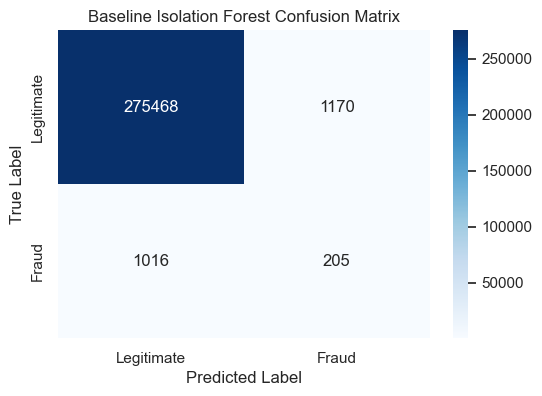

In [ ]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred_iso_test
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.title(
    "Baseline Isolation Forest Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred_iso_test,
        zero_division=0
    )
)


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    276638
           1       0.15      0.17      0.16      1221

    accuracy                           0.99    277859
   macro avg       0.57      0.58      0.58    277859
weighted avg       0.99      0.99      0.99    277859



In [ ]:
# ==========================================
# SAVE MODEL
# ==========================================

with open(
    "Saved Models/baseline_isolation_forest.pkl",
    "wb"
) as f:

    pickle.dump(
        iso_base,
        f
    )

print("\nBaseline Isolation Forest model saved!")


Baseline Isolation Forest model saved!


**LOF**

In [ ]:
# ==========================================
# BASELINE LOCAL OUTLIER FACTOR (LOF)
# ==========================================

from sklearn.neighbors import LocalOutlierFactor
import pickle

# ------------------------------------------
# TRAIN MODEL
# ------------------------------------------

lof_base = LocalOutlierFactor(
    n_neighbors=20,
    contamination=fraud_rate,
    novelty=True
)

lof_base.fit(
    X_train_pca
)

# ------------------------------------------
# TRAIN PREDICTIONS
# ------------------------------------------

scores_lof_train = normalize(
    -lof_base.decision_function(
        X_train_pca
    )
)

threshold_lof = np.percentile(
    scores_lof_train,
    100 * (1 - fraud_rate)
)

y_pred_lof_train = (
    scores_lof_train >= threshold_lof
).astype(int)

# ------------------------------------------
# TEST PREDICTIONS
# ------------------------------------------

scores_lof_test = normalize(
    -lof_base.decision_function(
        X_test_pca
    )
)

y_pred_lof_test = (
    scores_lof_test >= threshold_lof
).astype(int)

# ------------------------------------------
# OOT PREDICTIONS
# ------------------------------------------

scores_lof_oot = normalize(
    -lof_base.decision_function(
        X_oot_pca
    )
)

y_pred_lof_oot = (
    scores_lof_oot >= threshold_lof
).astype(int)

In [ ]:
# ==========================================
# METRICS
# ==========================================

print("\n==============================")
print("BASELINE LOCAL OUTLIER FACTOR")
print("==============================")

# ---------------- TRAIN ----------------

print("\nTRAIN")

print("Precision:",
      precision_score(
          y_train,
          y_pred_lof_train,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_train,
          y_pred_lof_train
      ))

print("F1:",
      f1_score(
          y_train,
          y_pred_lof_train
      ))

# ---------------- TEST ----------------

print("\nTEST")

print("Precision:",
      precision_score(
          y_test,
          y_pred_lof_test,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_lof_test
      ))

print("F1:",
      f1_score(
          y_test,
          y_pred_lof_test
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          scores_lof_test
      ))

print("Average Precision:",
      average_precision_score(
          y_test,
          scores_lof_test
      ))

# ---------------- OOT ----------------

print("\nOOT")

print("Precision:",
      precision_score(
          y_oot,
          y_pred_lof_oot,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_oot,
          y_pred_lof_oot
      ))

print("F1:",
      f1_score(
          y_oot,
          y_pred_lof_oot
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_oot,
          scores_lof_oot
      ))

print("Average Precision:",
      average_precision_score(
          y_oot,
          scores_lof_oot
      ))


BASELINE LOCAL OUTLIER FACTOR

TRAIN
Precision: 0.07420730082600586
Recall: 0.07420730082600586
F1: 0.07420730082600586

TEST
Precision: 0.004288361422394776
Recall: 0.39803439803439805
F1: 0.008485303489275519
ROC-AUC: 0.48664587957454447
Average Precision: 0.006324292505803572

OOT
Precision: 0.001312317636711388
Recall: 0.3051948051948052
F1: 0.0026133978342160503
ROC-AUC: 0.17282327690508642
Average Precision: 0.0018407504538112758


In [ ]:
# ==========================================
# PREDICTED ANOMALY ANALYSIS
# ==========================================

print("\n==============================")
print("PREDICTED ANOMALIES")
print("==============================")

anomalies = y_pred_lof_test == 1

actual = y_test[anomalies]

print("Total Test Transactions:",
      len(y_test))

print("Predicted Anomalies:",
      anomalies.sum())

print("Actual Frauds:",
      y_test.sum())

print("Frauds within Anomalies:",
      actual.sum())

print("Legitimate within Anomalies:",
      len(actual) - actual.sum())

print()

print("Precision:",
      precision_score(
          y_test,
          y_pred_lof_test,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_lof_test
      ))

print("F1:",
      f1_score(
          y_test,
          y_pred_lof_test
      ))


PREDICTED ANOMALIES
Total Test Transactions: 277859
Predicted Anomalies: 113330
Actual Frauds: 1221
Frauds within Anomalies: 486
Legitimate within Anomalies: 112844

Precision: 0.004288361422394776
Recall: 0.39803439803439805
F1: 0.008485303489275519


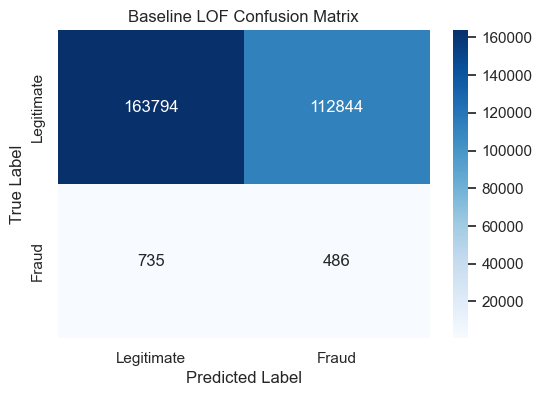

In [ ]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred_lof_test
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.title("Baseline LOF Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred_lof_test,
        zero_division=0
    )
)


Classification Report
              precision    recall  f1-score   support

           0       1.00      0.59      0.74    276638
           1       0.00      0.40      0.01      1221

    accuracy                           0.59    277859
   macro avg       0.50      0.50      0.38    277859
weighted avg       0.99      0.59      0.74    277859



In [ ]:
# ==========================================
# SAVE MODEL
# ==========================================

with open(
    "baseline_lof.pkl",
    "wb"
) as f:

    pickle.dump(
        lof_base,
        f
    )

print("\nBaseline LOF model saved!")


Baseline LOF model saved!


**ONE-CLASS SVM**

In [ ]:
# ==========================================
# BASELINE ONE-CLASS SUPPORT VECTOR MACHINE
# ==========================================

from sklearn.svm import OneClassSVM
from sklearn.preprocessing import MinMaxScaler
import pickle

# ------------------------------------------
# SCALE DATA
# ------------------------------------------

svm_scaler_base = MinMaxScaler()

X_train_svm = svm_scaler_base.fit_transform(
    X_train_pca
)

X_test_svm = svm_scaler_base.transform(
    X_test_pca
)

X_oot_svm = svm_scaler_base.transform(
    X_oot_pca
)

# ------------------------------------------
# TRAIN MODEL
# ------------------------------------------

svm_base = OneClassSVM(
    nu=fraud_rate,
    kernel="rbf",
    gamma="scale"
)

svm_base.fit(
    X_train_svm
)

# ------------------------------------------
# TRAIN PREDICTIONS
# ------------------------------------------

scores_svm_train = normalize(
    -svm_base.decision_function(
        X_train_svm
    )
)

threshold_svm = np.percentile(
    scores_svm_train,
    100 * (1 - fraud_rate)
)

y_pred_svm_train = (
    scores_svm_train >= threshold_svm
).astype(int)

# ------------------------------------------
# TEST PREDICTIONS
# ------------------------------------------

scores_svm_test = normalize(
    -svm_base.decision_function(
        X_test_svm
    )
)

y_pred_svm_test = (
    scores_svm_test >= threshold_svm
).astype(int)

# ------------------------------------------
# OOT PREDICTIONS
# ------------------------------------------

scores_svm_oot = normalize(
    -svm_base.decision_function(
        X_oot_svm
    )
)

y_pred_svm_oot = (
    scores_svm_oot >= threshold_svm
).astype(int)

In [ ]:
# ==========================================
# METRICS
# ==========================================

print("\n==============================")
print("BASELINE ONE-CLASS SVM")
print("==============================")

# ---------------- TRAIN ----------------

print("\n---------------- TRAIN ----------------")

print("Precision:",
      precision_score(
          y_train,
          y_pred_svm_train,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_train,
          y_pred_svm_train
      ))

print("F1:",
      f1_score(
          y_train,
          y_pred_svm_train
      ))

# ---------------- TEST ----------------

print("\n---------------- TEST ----------------")

print("Precision:",
      precision_score(
          y_test,
          y_pred_svm_test,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_svm_test
      ))

print("F1:",
      f1_score(
          y_test,
          y_pred_svm_test
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          scores_svm_test
      ))

print("Average Precision:",
      average_precision_score(
          y_test,
          scores_svm_test
      ))

# ---------------- OOT ----------------

print("\n---------------- OOT ----------------")

print("Precision:",
      precision_score(
          y_oot,
          y_pred_svm_oot,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_oot,
          y_pred_svm_oot
      ))

print("F1:",
      f1_score(
          y_oot,
          y_pred_svm_oot
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_oot,
          scores_svm_oot
      ))

print("Average Precision:",
      average_precision_score(
          y_oot,
          scores_svm_oot
      ))


BASELINE ONE-CLASS SVM

---------------- TRAIN ----------------
Precision: 0.04343192112976286
Recall: 0.04343192112976286
F1: 0.04343192112976286

---------------- TEST ----------------
Precision: 0.0012154381974553985
Recall: 0.14004914004914004
F1: 0.0024099611728477708
ROC-AUC: 0.43460224074962467
Average Precision: 0.02111821158329294

---------------- OOT ----------------
Precision: 0.0008346648224548685
Recall: 0.11363636363636363
F1: 0.0016571577377429512
ROC-AUC: 0.4354628890767204
Average Precision: 0.011680490994653962


In [ ]:
# ==========================================
# PREDICTED ANOMALY ANALYSIS
# ==========================================

print("\n==============================")
print("PREDICTED ANOMALIES")
print("==============================")

anomalies = y_pred_svm_test == 1

actual = y_test[anomalies]

print("Total Test Transactions:",
      len(y_test))

print("Predicted Anomalies:",
      anomalies.sum())

print("Actual Frauds:",
      y_test.sum())

print("Frauds within Anomalies:",
      actual.sum())

print("Legitimate within Anomalies:",
      len(actual) - actual.sum())

print()

print("Precision:",
      precision_score(
          y_test,
          y_pred_svm_test,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_svm_test
      ))

print("F1:",
      f1_score(
          y_test,
          y_pred_svm_test
      ))


PREDICTED ANOMALIES
Total Test Transactions: 277859
Predicted Anomalies: 140690
Actual Frauds: 1221
Frauds within Anomalies: 171
Legitimate within Anomalies: 140519

Precision: 0.0012154381974553985
Recall: 0.14004914004914004
F1: 0.0024099611728477708


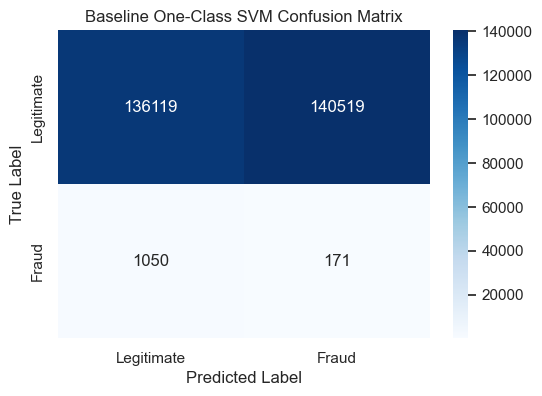

In [ ]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred_svm_test
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.title(
    "Baseline One-Class SVM Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred_svm_test,
        zero_division=0
    )
)


Classification Report
              precision    recall  f1-score   support

           0       0.99      0.49      0.66    276638
           1       0.00      0.14      0.00      1221

    accuracy                           0.49    277859
   macro avg       0.50      0.32      0.33    277859
weighted avg       0.99      0.49      0.66    277859



In [ ]:
# ==========================================
# SAVE MODEL
# ==========================================

with open(
    "Saved Models/baseline_oneclass_svm.pkl",
    "wb"
) as f:

    pickle.dump(
        svm_base,
        f
    )

print("\nBaseline One-Class SVM model saved!")

with open(
    "Saved Models/baseline_svm_scaler.pkl",
    "wb"
) as f:

    pickle.dump(
        svm_scaler_base,
        f
    )

print("Baseline SVM scaler saved!")


Baseline One-Class SVM model saved!
Baseline SVM scaler saved!


**TUNED**

**ISO**

In [ ]:
# ==========================================
# TUNED ISOLATION FOREST
# ==========================================

from sklearn.ensemble import IsolationForest
import pickle

# ------------------------------------------
# HYPERPARAMETER SEARCH
# ------------------------------------------

best_c = None
best_f1_iso = 0

for c in [0.003, 0.005, 0.01]:

    iso_tmp = IsolationForest(
        contamination=c,
        random_state=42
    )

    iso_tmp.fit(
        X_train_pca
    )

    # ------------------------------------------
    # TRAIN THRESHOLD
    # ------------------------------------------

    scores_train_tmp = normalize(
        -iso_tmp.decision_function(
            X_train_pca
        )
    )

    threshold_tmp = np.percentile(
        scores_train_tmp,
        100 * (1 - fraud_rate)
    )

    # ------------------------------------------
    # TEST PREDICTIONS
    # ------------------------------------------

    scores_test_tmp = normalize(
        -iso_tmp.decision_function(
            X_test_pca
        )
    )

    y_tmp = (
        scores_test_tmp >= threshold_tmp
    ).astype(int)

    f1_tmp = f1_score(
        y_test,
        y_tmp
    )

    print(
        f"Contamination={c} | Test F1={f1_tmp:.4f}"
    )

    if f1_tmp > best_f1_iso:

        best_f1_iso = f1_tmp
        best_c = c

print("\nBest contamination:", best_c)

# ------------------------------------------
# FINAL MODEL
# ------------------------------------------

iso = IsolationForest(
    contamination=best_c,
    random_state=42
)

iso.fit(
    X_train_pca
)

# ------------------------------------------
# TRAIN
# ------------------------------------------

scores_iso_train = normalize(
    -iso.decision_function(
        X_train_pca
    )
)

threshold_iso = np.percentile(
    scores_iso_train,
    100 * (1 - fraud_rate)
)

y_pred_iso_train = (
    scores_iso_train >= threshold_iso
).astype(int)

# ------------------------------------------
# TEST
# ------------------------------------------

scores_iso_test = normalize(
    -iso.decision_function(
        X_test_pca
    )
)

y_pred_iso_test = (
    scores_iso_test >= threshold_iso
).astype(int)

# ------------------------------------------
# OOT
# ------------------------------------------

scores_iso_oot = normalize(
    -iso.decision_function(
        X_oot_pca
    )
)

y_pred_iso_oot = (
    scores_iso_oot >= threshold_iso
).astype(int)

Contamination=0.003 | Test F1=0.1579
Contamination=0.005 | Test F1=0.1579
Contamination=0.01 | Test F1=0.1579

Best contamination: 0.003


In [ ]:
# ==========================================
# METRICS
# ==========================================

print("\n==============================")
print("TUNED ISOLATION FOREST")
print("==============================")

# ---------------- TRAIN ----------------

print("\n---------------- TRAIN ----------------")

print("Precision:",
      precision_score(
          y_train,
          y_pred_iso_train,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_train,
          y_pred_iso_train
      ))

print("F1:",
      f1_score(
          y_train,
          y_pred_iso_train
      ))

# ---------------- TEST ----------------

print("\n---------------- TEST ----------------")

print("Precision:",
      precision_score(
          y_test,
          y_pred_iso_test,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_iso_test
      ))

print("F1:",
      f1_score(
          y_test,
          y_pred_iso_test
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          scores_iso_test
      ))

print("Average Precision:",
      average_precision_score(
          y_test,
          scores_iso_test
      ))

# ---------------- OOT ----------------

print("\n---------------- OOT ----------------")

print("Precision:",
      precision_score(
          y_oot,
          y_pred_iso_oot,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_oot,
          y_pred_iso_oot
      ))

print("F1:",
      f1_score(
          y_oot,
          y_pred_iso_oot
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_oot,
          scores_iso_oot
      ))

print("Average Precision:",
      average_precision_score(
          y_oot,
          scores_iso_oot
      ))


TUNED ISOLATION FOREST

---------------- TRAIN ----------------
Precision: 0.11510791366906475
Recall: 0.11510791366906475
F1: 0.11510791366906475

---------------- TEST ----------------
Precision: 0.14909090909090908
Recall: 0.1678951678951679
F1: 0.15793528505392912
ROC-AUC: 0.8085137683873215
Average Precision: 0.06843483234965289

---------------- OOT ----------------
Precision: 0.06042553191489362
Recall: 0.15367965367965367
F1: 0.08674404398289554
ROC-AUC: 0.7521936359059376
Average Precision: 0.029257502186434296


In [ ]:
# ==========================================
# PREDICTED ANOMALY ANALYSIS
# ==========================================

print("\n==============================")
print("PREDICTED ANOMALIES")
print("==============================")

anomalies = y_pred_iso_test == 1

actual = y_test[anomalies]

print("Total Test Transactions:",
      len(y_test))

print("Predicted Anomalies:",
      anomalies.sum())

print("Actual Frauds:",
      y_test.sum())

print("Frauds within Anomalies:",
      actual.sum())

print("Legitimate within Anomalies:",
      len(actual) - actual.sum())

print()

print("Precision:",
      precision_score(
          y_test,
          y_pred_iso_test,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_iso_test
      ))

print("F1:",
      f1_score(
          y_test,
          y_pred_iso_test
      ))


PREDICTED ANOMALIES
Total Test Transactions: 277859
Predicted Anomalies: 1375
Actual Frauds: 1221
Frauds within Anomalies: 205
Legitimate within Anomalies: 1170

Precision: 0.14909090909090908
Recall: 0.1678951678951679
F1: 0.15793528505392912


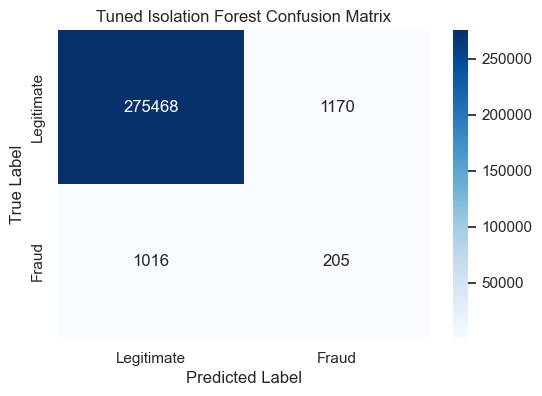

In [ ]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred_iso_test
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.title(
    "Tuned Isolation Forest Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred_iso_test,
        zero_division=0
    )
)


Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    276638
           1       0.15      0.17      0.16      1221

    accuracy                           0.99    277859
   macro avg       0.57      0.58      0.58    277859
weighted avg       0.99      0.99      0.99    277859



In [ ]:
# ==========================================
# SAVE MODEL
# ==========================================

with open(
    "Saved Models/tuned_isolation_forest.pkl",
    "wb"
) as f:

    pickle.dump(
        iso,
        f
    )

print("\nTuned Isolation Forest model saved!")


Tuned Isolation Forest model saved!


**LOF**

In [ ]:
# ==========================================
# TUNED LOCAL OUTLIER FACTOR (LOF)
# ==========================================

from sklearn.neighbors import LocalOutlierFactor
import pickle

# ------------------------------------------
# HYPERPARAMETER SEARCH
# ------------------------------------------

best_k = None
best_f1_lof = 0

for k in [10, 20, 50, 100]:

    lof_tmp = LocalOutlierFactor(
        n_neighbors=k,
        contamination=fraud_rate,
        novelty=True
    )

    lof_tmp.fit(
        X_train_pca
    )

    # ------------------------------------------
    # TRAIN THRESHOLD
    # ------------------------------------------

    scores_train_tmp = normalize(
        -lof_tmp.decision_function(
            X_train_pca
        )
    )

    threshold_tmp = np.percentile(
        scores_train_tmp,
        100 * (1 - fraud_rate)
    )

    # ------------------------------------------
    # TEST PREDICTIONS
    # ------------------------------------------

    scores_test_tmp = normalize(
        -lof_tmp.decision_function(
            X_test_pca
        )
    )

    y_tmp = (
        scores_test_tmp >= threshold_tmp
    ).astype(int)

    f1_tmp = f1_score(
        y_test,
        y_tmp
    )

    print(
        f"Neighbors={k} | Test F1={f1_tmp:.4f}"
    )

    if f1_tmp > best_f1_lof:

        best_f1_lof = f1_tmp
        best_k = k

print("\nBest number of neighbors:", best_k)

# ------------------------------------------
# FINAL MODEL
# ------------------------------------------

lof = LocalOutlierFactor(
    n_neighbors=best_k,
    contamination=fraud_rate,
    novelty=True
)

lof.fit(
    X_train_pca
)

# ------------------------------------------
# TRAIN
# ------------------------------------------

scores_lof_train = normalize(
    -lof.decision_function(
        X_train_pca
    )
)

threshold_lof = np.percentile(
    scores_lof_train,
    100 * (1 - fraud_rate)
)

y_pred_lof_train = (
    scores_lof_train >= threshold_lof
).astype(int)

# ------------------------------------------
# TEST
# ------------------------------------------

scores_lof_test = normalize(
    -lof.decision_function(
        X_test_pca
    )
)

y_pred_lof_test = (
    scores_lof_test >= threshold_lof
).astype(int)

# ------------------------------------------
# OOT
# ------------------------------------------

scores_lof_oot = normalize(
    -lof.decision_function(
        X_oot_pca
    )
)

y_pred_lof_oot = (
    scores_lof_oot >= threshold_lof
).astype(int)

Neighbors=10 | Test F1=0.0072
Neighbors=20 | Test F1=0.0085
Neighbors=50 | Test F1=0.0102
Neighbors=100 | Test F1=0.0125

Best number of neighbors: 100


In [ ]:
# ==========================================
# METRICS
# ==========================================

print("\n==============================")
print("TUNED LOCAL OUTLIER FACTOR")
print("==============================")

# ---------------- TRAIN ----------------

print("\n---------------- TRAIN ----------------")

print("Precision:",
      precision_score(
          y_train,
          y_pred_lof_train,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_train,
          y_pred_lof_train
      ))

print("F1:",
      f1_score(
          y_train,
          y_pred_lof_train
      ))

# ---------------- TEST ----------------

print("\n---------------- TEST ----------------")

print("Precision:",
      precision_score(
          y_test,
          y_pred_lof_test,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_lof_test
      ))

print("F1:",
      f1_score(
          y_test,
          y_pred_lof_test
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          scores_lof_test
      ))

print("Average Precision:",
      average_precision_score(
          y_test,
          scores_lof_test
      ))

# ---------------- OOT ----------------

print("\n---------------- OOT ----------------")

print("Precision:",
      precision_score(
          y_oot,
          y_pred_lof_oot,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_oot,
          y_pred_lof_oot
      ))

print("F1:",
      f1_score(
          y_oot,
          y_pred_lof_oot
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_oot,
          scores_lof_oot
      ))

print("Average Precision:",
      average_precision_score(
          y_oot,
          scores_lof_oot
      ))


TUNED LOCAL OUTLIER FACTOR

---------------- TRAIN ----------------
Precision: 0.0903277378097522
Recall: 0.0903277378097522
F1: 0.0903277378097522

---------------- TEST ----------------
Precision: 0.0063058673612802875
Recall: 0.5511875511875511
F1: 0.012469082049524304
ROC-AUC: 0.6095511811682403
Average Precision: 0.011588801703163829

---------------- OOT ----------------
Precision: 0.0018591712872770868
Recall: 0.4296536796536797
F1: 0.003702322111349436
ROC-AUC: 0.244842241356779
Average Precision: 0.002006322800321198


In [ ]:
# ==========================================
# PREDICTED ANOMALY ANALYSIS
# ==========================================

print("\n==============================")
print("PREDICTED ANOMALIES")
print("==============================")

anomalies = y_pred_lof_test == 1

actual = y_test[anomalies]

print("Total Test Transactions:",
      len(y_test))

print("Predicted Anomalies:",
      anomalies.sum())

print("Actual Frauds:",
      y_test.sum())

print("Frauds within Anomalies:",
      actual.sum())

print("Legitimate within Anomalies:",
      len(actual) - actual.sum())

print()

print("Precision:",
      precision_score(
          y_test,
          y_pred_lof_test,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_lof_test
      ))

print("F1:",
      f1_score(
          y_test,
          y_pred_lof_test
      ))


PREDICTED ANOMALIES
Total Test Transactions: 277859
Predicted Anomalies: 106726
Actual Frauds: 1221
Frauds within Anomalies: 673
Legitimate within Anomalies: 106053

Precision: 0.0063058673612802875
Recall: 0.5511875511875511
F1: 0.012469082049524304


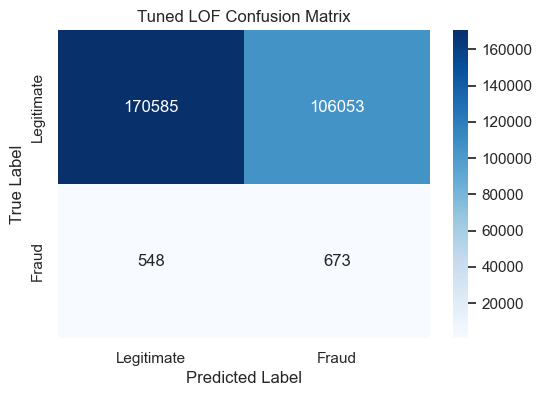

In [ ]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred_lof_test
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.title(
    "Tuned LOF Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred_lof_test,
        zero_division=0
    )
)


Classification Report
              precision    recall  f1-score   support

           0       1.00      0.62      0.76    276638
           1       0.01      0.55      0.01      1221

    accuracy                           0.62    277859
   macro avg       0.50      0.58      0.39    277859
weighted avg       0.99      0.62      0.76    277859



In [ ]:
# ==========================================
# SAVE MODEL
# ==========================================

with open(
    "Saved Models/tuned_lof.pkl",
    "wb"
) as f:

    pickle.dump(
        lof,
        f
    )

print("\nTuned LOF model saved!")


Tuned LOF model saved!


**ONE_CLASS SVM**

In [ ]:
# ==========================================
# TUNED ONE-CLASS SUPPORT VECTOR MACHINE
# ==========================================

from sklearn.svm import OneClassSVM
from sklearn.preprocessing import MinMaxScaler
import pickle

# ------------------------------------------
# SCALE DATA
# ------------------------------------------

svm_scaler = MinMaxScaler()

X_train_svm = svm_scaler.fit_transform(
    X_train_pca
)

X_test_svm = svm_scaler.transform(
    X_test_pca
)

X_oot_svm = svm_scaler.transform(
    X_oot_pca
)

# ------------------------------------------
# TRAIN MODEL
# ------------------------------------------

svm = OneClassSVM(
    nu=fraud_rate,
    kernel="rbf",
    gamma="scale"
)

svm.fit(
    X_train_svm
)

# ------------------------------------------
# TRAIN
# ------------------------------------------

scores_svm_train = normalize(
    -svm.decision_function(
        X_train_svm
    )
)

threshold_svm = np.percentile(
    scores_svm_train,
    100 * (1 - fraud_rate)
)

y_pred_svm_train = (
    scores_svm_train >= threshold_svm
).astype(int)

# ------------------------------------------
# TEST
# ------------------------------------------

scores_svm_test = normalize(
    -svm.decision_function(
        X_test_svm
    )
)

y_pred_svm_test = (
    scores_svm_test >= threshold_svm
).astype(int)

# ------------------------------------------
# OOT
# ------------------------------------------

scores_svm_oot = normalize(
    -svm.decision_function(
        X_oot_svm
    )
)

y_pred_svm_oot = (
    scores_svm_oot >= threshold_svm
).astype(int)

In [ ]:
# ==========================================
# METRICS
# ==========================================

print("\n==============================")
print("TUNED ONE-CLASS SVM")
print("==============================")

# ---------------- TRAIN ----------------

print("\n---------------- TRAIN ----------------")

print("Precision:",
      precision_score(
          y_train,
          y_pred_svm_train,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_train,
          y_pred_svm_train
      ))

print("F1:",
      f1_score(
          y_train,
          y_pred_svm_train
      ))

# ---------------- TEST ----------------

print("\n---------------- TEST ----------------")

print("Precision:",
      precision_score(
          y_test,
          y_pred_svm_test,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_svm_test
      ))

print("F1:",
      f1_score(
          y_test,
          y_pred_svm_test
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_test,
          scores_svm_test
      ))

print("Average Precision:",
      average_precision_score(
          y_test,
          scores_svm_test
      ))

# ---------------- OOT ----------------

print("\n---------------- OOT ----------------")

print("Precision:",
      precision_score(
          y_oot,
          y_pred_svm_oot,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_oot,
          y_pred_svm_oot
      ))

print("F1:",
      f1_score(
          y_oot,
          y_pred_svm_oot
      ))

print("ROC-AUC:",
      roc_auc_score(
          y_oot,
          scores_svm_oot
      ))

print("Average Precision:",
      average_precision_score(
          y_oot,
          scores_svm_oot
      ))


TUNED ONE-CLASS SVM

---------------- TRAIN ----------------
Precision: 0.04343192112976286
Recall: 0.04343192112976286
F1: 0.04343192112976286

---------------- TEST ----------------
Precision: 0.0012154381974553985
Recall: 0.14004914004914004
F1: 0.0024099611728477708
ROC-AUC: 0.43460224074962467
Average Precision: 0.02111821158329294

---------------- OOT ----------------
Precision: 0.0008346648224548685
Recall: 0.11363636363636363
F1: 0.0016571577377429512
ROC-AUC: 0.4354628890767204
Average Precision: 0.011680490994653962


In [ ]:
# ==========================================
# PREDICTED ANOMALY ANALYSIS
# ==========================================

print("\n==============================")
print("PREDICTED ANOMALIES")
print("==============================")

anomalies = y_pred_svm_test == 1

actual = y_test[anomalies]

print("Total Test Transactions:",
      len(y_test))

print("Predicted Anomalies:",
      anomalies.sum())

print("Actual Frauds:",
      y_test.sum())

print("Frauds within Anomalies:",
      actual.sum())

print("Legitimate within Anomalies:",
      len(actual) - actual.sum())

print()

print("Precision:",
      precision_score(
          y_test,
          y_pred_svm_test,
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_test,
          y_pred_svm_test
      ))

print("F1:",
      f1_score(
          y_test,
          y_pred_svm_test
      ))


PREDICTED ANOMALIES
Total Test Transactions: 277859
Predicted Anomalies: 140690
Actual Frauds: 1221
Frauds within Anomalies: 171
Legitimate within Anomalies: 140519

Precision: 0.0012154381974553985
Recall: 0.14004914004914004
F1: 0.0024099611728477708


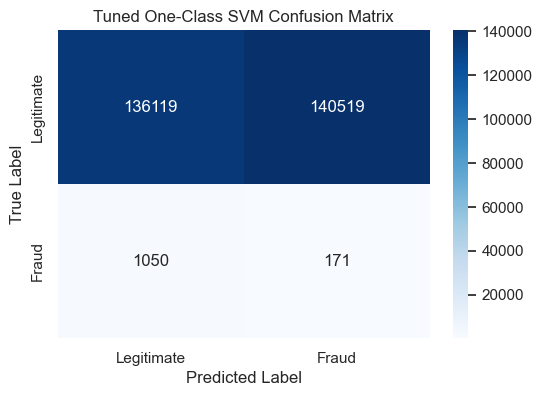

In [ ]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred_svm_test
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.title(
    "Tuned One-Class SVM Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred_svm_test,
        zero_division=0
    )
)


Classification Report
              precision    recall  f1-score   support

           0       0.99      0.49      0.66    276638
           1       0.00      0.14      0.00      1221

    accuracy                           0.49    277859
   macro avg       0.50      0.32      0.33    277859
weighted avg       0.99      0.49      0.66    277859



In [ ]:
# ==========================================
# SAVE MODEL
# ==========================================

with open(
    "Saved Models/tuned_oneclass_svm.pkl",
    "wb"
) as f:

    pickle.dump(
        svm,
        f
    )

with open(
    "Saved Models/tuned_svm_scaler.pkl",
    "wb"
) as f:

    pickle.dump(
        svm_scaler,
        f
    )

print("\nTuned One-Class SVM model saved!")
print("Tuned SVM scaler saved!")

with open(
    "Saved Models/pca.pkl",
    "wb"
) as f:

    pickle.dump(
        pca,
        f
    )

print("PCA saved!")


Tuned One-Class SVM model saved!
Tuned SVM scaler saved!
PCA saved!
